# Análise multianual de indicadores do PPGEEC (2021–2024)



In [ ]:
def build_2024_as_legacy_long_raw(sheets_raw, excel_name=None):
    prod = sheets_raw["Produções"].copy()
    aut = sheets_raw["Produções - Autores"].copy()
    det = sheets_raw["Produções - Detalhes"].copy()

    prod = prod.rename(columns={
        "Nome da Produção": "Título da Produção",
        "Tipo de Produção": "Tipo da Produção",
        "Subtipo de Produção": "Subtipo da Produção",
        "Projeto": "Projeto de Pesquisa",
    })

    aut = aut.rename(columns={
        "Nome da Produção": "Título da Produção",
        "Tipo de Produção": "Tipo da Produção",
        "Subtipo de Produção": "Subtipo da Produção",
        "Projeto": "Projeto de Pesquisa",
        "Número de Ordem do Autor": "Número de Ordem Autor",
    })

    det = det.rename(columns={
        "Nome da Produção": "Título da Produção",
        "Tipo de Produção": "Tipo da Produção",
        "Subtipo de Produção": "Subtipo da Produção",
        "Projeto": "Projeto de Pesquisa",
        "Item de Detalhamento": "Nome do Detalhamento",
        "Valor do Item de Detalhamento": "Valor do Detalhamento",
    })

    if "Nome do PPG" not in prod.columns and "Nome do PPG" in aut.columns:
        mapa_ppg = aut[["Código do PPG", "Nome do PPG"]].drop_duplicates()
        prod = prod.merge(mapa_ppg, on="Código do PPG", how="left")

    legacy_cols = [
        "Calendário",
        "Ano do Calendário",
        "Data-Hora do Envio",
        "Código do PPG",
        "Nome do PPG",
        "Área de Avaliação",
        "IES Sigla",
        "IES Nome",
        "Ano da Produção",
        "Título da Produção",
        "Produção Glosada?",
        "Tipo da Produção",
        "Subtipo da Produção",
        "Área de Concentração",
        "Linha de Pesquisa",
        "Projeto de Pesquisa",
        "Nome do Detalhamento",
        "Valor do Detalhamento",
        "Nome do Autor",
        "Categoria do Autor",
        "Número de Ordem Autor",
    ]

    det_base_cols = [
        "Código do PPG",
        "Nome do PPG",
        "Área de Avaliação",
        "IES Sigla",
        "IES Nome",
        "Ano da Produção",
        "Título da Produção",
        "Tipo da Produção",
        "Subtipo da Produção",
        "Área de Concentração",
        "Linha de Pesquisa",
        "Projeto de Pesquisa",
        "Nome do Detalhamento",
        "Valor do Detalhamento",
    ]
    det_base_cols = [c for c in det_base_cols if c in det.columns]

    linhas_detalhes = det[det_base_cols].copy()

    for c in legacy_cols:
        if c not in linhas_detalhes.columns:
            linhas_detalhes[c] = pd.NA

    linhas_detalhes = linhas_detalhes[legacy_cols]

    if "ISSN" in prod.columns:
        issn_extra_cols = [
            "Código do PPG",
            "Nome do PPG",
            "Área de Avaliação",
            "IES Sigla",
            "IES Nome",
            "Ano da Produção",
            "Título da Produção",
            "Tipo da Produção",
            "Subtipo da Produção",
            "Área de Concentração",
            "Linha de Pesquisa",
            "Projeto de Pesquisa",
            "ISSN",
        ]
        issn_extra_cols = [c for c in issn_extra_cols if c in prod.columns]

        issn_extra = prod[issn_extra_cols].copy()
        issn_extra = issn_extra[issn_extra["ISSN"].notna()].copy()
        issn_extra["Nome do Detalhamento"] = "ISSN / Título do periódico"
        issn_extra["Valor do Detalhamento"] = issn_extra["ISSN"]

        for c in legacy_cols:
            if c not in issn_extra.columns:
                issn_extra[c] = pd.NA

        issn_extra = issn_extra[legacy_cols]
        linhas_detalhes = pd.concat([linhas_detalhes, issn_extra], ignore_index=True)

    if "Estrato" in prod.columns:
        estrato_extra_cols = [
            "Código do PPG",
            "Nome do PPG",
            "Área de Avaliação",
            "IES Sigla",
            "IES Nome",
            "Ano da Produção",
            "Título da Produção",
            "Tipo da Produção",
            "Subtipo da Produção",
            "Área de Concentração",
            "Linha de Pesquisa",
            "Projeto de Pesquisa",
            "Estrato",
        ]
        estrato_extra_cols = [c for c in estrato_extra_cols if c in prod.columns]

        estrato_extra = prod[estrato_extra_cols].copy()
        estrato_extra = estrato_extra[estrato_extra["Estrato"].notna()].copy()
        estrato_extra["Nome do Detalhamento"] = "Estrato Informado"
        estrato_extra["Valor do Detalhamento"] = estrato_extra["Estrato"]

        for c in legacy_cols:
            if c not in estrato_extra.columns:
                estrato_extra[c] = pd.NA

        estrato_extra = estrato_extra[legacy_cols]
        linhas_detalhes = pd.concat([linhas_detalhes, estrato_extra], ignore_index=True)

    aut_base_cols = [
        "Código do PPG",
        "Nome do PPG",
        "Área de Avaliação",
        "IES Sigla",
        "IES Nome",
        "Ano da Produção",
        "Título da Produção",
        "Tipo da Produção",
        "Subtipo da Produção",
        "Área de Concentração",
        "Linha de Pesquisa",
        "Projeto de Pesquisa",
        "Nome do Autor",
        "Categoria do Autor",
        "Número de Ordem Autor",
    ]
    aut_base_cols = [c for c in aut_base_cols if c in aut.columns]

    linhas_autores = aut[aut_base_cols].copy()

    for c in legacy_cols:
        if c not in linhas_autores.columns:
            linhas_autores[c] = pd.NA

    linhas_autores = linhas_autores[legacy_cols]

    out = pd.concat([linhas_detalhes, linhas_autores], ignore_index=True)
    out = out.drop_duplicates().reset_index(drop=True)

    if excel_name is not None:
        out["arquivo_origem_2024"] = excel_name

    return out

In [ ]:
from pathlib import Path
import re
import unicodedata
from pathlib import Path


EXCEL_2024_PATH = "conferencia_2024.xls"

def load_excel_sheets(excel_path):
    xls = pd.ExcelFile(excel_path)
    return {sheet_name: pd.read_excel(excel_path, sheet_name=sheet_name) for sheet_name in xls.sheet_names}

sheets_2024_raw = load_excel_sheets(EXCEL_2024_PATH)
producao_2024_legado = build_2024_as_legacy_long_raw(
    sheets_2024_raw,
    excel_name="ppgeec_2024.xls"
)


OUTPUT_2024_LEGADO = "2024_coleta.xlsx"

with pd.ExcelWriter(OUTPUT_2024_LEGADO) as writer:
    producao_2024_legado.to_excel(
        writer,
        index=False,
        sheet_name="Produções Intelectuais"
    )

print("Arquivo salvo:", OUTPUT_2024_LEGADO)

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default sty

Arquivo salvo: 2024_coleta.xlsx


In [ ]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

EXCEL_PATHS = [
    "2021_coleta.xlsx",
    "2022_coleta.xlsx",
    "2023_coleta.xlsx",
    "2024_coleta.xlsx",
]

QUALIS_PATH = "qualis_capes.xlsx"
OUTPUT_DIR = Path("saida_indicadores_ppgeec_multianual")
OUTPUT_DIR.mkdir(exist_ok=True)

PRODUCAO_SHEET_CANDIDATES = [
    "Produções Intelectuais", "Producoes Intelectuais", "Produção Intelectual", "Producoes", "Produção"
]

MISSING_TOKENS = {"", "-", "--", "---", "na", "n/a", "null", "none", "nan", "não informado", "nao informado", "sem informacao", "sem informação", "ignorado"}
BOOLEAN_TRUE = {"sim", "s", "true", "1", "yes"}
BOOLEAN_FALSE = {"nao", "não", "n", "false", "0", "no"}

# **1. Mecanismos de limpeza aplicados para a base**

## 1.1 Mecanismos gerais para os dados
- padronização textual;
- tratamento de placeholders de ausência;
- detecção de sujeira;
- inferência de tipos.

## 1.2 **Estratégia para a aba de Produções Intelectuais**:  
Dados que precisam ser preservados
- autores;
- ordem dos autores;
- detalhamentos como ISSN, DOI, idioma e periódico.

In [ ]:
def normalize_text(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    text = re.sub(r"\s+", " ", text)
    text_ascii = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    if text_ascii.lower().strip() in MISSING_TOKENS:
        return np.nan
    return text

def snake_case(text):
    if text is None:
        return text
    text = unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode("utf-8")
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text

def is_probably_date(series, threshold=0.7):
    if series.dropna().empty:
        return False
    return pd.to_datetime(series, errors="coerce", dayfirst=True).notna().mean() >= threshold

def is_probably_numeric(series, threshold=0.8):
    if series.dropna().empty:
        return False
    coerced = pd.to_numeric(series.astype(str).str.replace(",", ".", regex=False), errors="coerce")
    return coerced.notna().mean() >= threshold

def is_probably_boolean(series, threshold=0.9):
    if series.dropna().empty:
        return False
    vals = (series.dropna().astype(str).str.strip().str.lower()
            .map(lambda x: unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")))
    return vals.isin(BOOLEAN_TRUE.union(BOOLEAN_FALSE)).mean() >= threshold

def standardize_dataframe(df):
    out = df.copy().dropna(axis=1, how="all")
    for col in out.columns:
        if out[col].dtype == "object":
            out[col] = out[col].map(normalize_text)
    return out

def describe_column_type(series):
    s = series.copy()
    if pd.api.types.is_datetime64_any_dtype(s):
        logical = "datetime"
    elif pd.api.types.is_numeric_dtype(s):
        logical = "numerico"
    elif is_probably_date(s):
        logical = "data_textual"
    elif is_probably_numeric(s):
        logical = "numerico_textual"
    elif is_probably_boolean(s):
        logical = "booleano_textual"
    else:
        nunique = s.nunique(dropna=True)
        total = max(len(s.dropna()), 1)
        logical = "categorica_textual" if (nunique / total) < 0.5 else "texto_livre"

    return {
        "dtype_pandas": str(s.dtype),
        "tipo_logico": logical,
        "n_total": int(len(s)),
        "n_na": int(s.isna().sum()),
        "pct_na": round(float(s.isna().mean() * 100), 2) if len(s) else 0.0,
        "n_unicos": int(s.nunique(dropna=True)),
    }

def detect_dirty_patterns(df):
    rows = []
    for col in df.columns:
        s = df[col]
        total = len(s)
        if s.dtype == "object":
            raw = s.astype(str)
            spaces_edge = int((raw != raw.str.strip()).sum())
            multi_spaces = int(raw.str.contains(r"\s{2,}", regex=True, na=False).sum())
            empty_like = int(
                s.fillna("").astype(str).str.strip().str.lower()
                 .map(lambda x: unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8"))
                 .isin(MISSING_TOKENS).sum()
            )
        else:
            spaces_edge = 0
            multi_spaces = 0
            empty_like = 0

        invalid_dates = 0
        if is_probably_date(s):
            parsed = pd.to_datetime(s, errors="coerce", dayfirst=True)
            invalid_dates = max(0, int(parsed.isna().sum() - s.isna().sum()))

        n_nulos = int(s.isna().sum())
        pct_nulos = round(float(n_nulos / total * 100), 2) if total else 0.0
        n_unicos = int(s.nunique(dropna=True))
        coluna_constante = int(n_unicos <= 1)

        score = pct_nulos * 2 + empty_like * 1.5 + invalid_dates * 1.5 + spaces_edge + multi_spaces + coluna_constante * 10

        rows.append({
            "coluna": col,
            "nulos": n_nulos,
            "pct_nulos": pct_nulos,
            "espacos_inicio_fim": spaces_edge,
            "multiplos_espacos": multi_spaces,
            "placeholders_ausencia": empty_like,
            "datas_invalidas": invalid_dates,
            "valores_unicos": n_unicos,
            "coluna_constante": coluna_constante,
            "score_sujeira": round(score, 2),
        })
    return pd.DataFrame(rows).sort_values("score_sujeira", ascending=False).reset_index(drop=True)

| Nome da Função | Descrição Resumida |
| :--- | :--- |
| `normalize_text` | Limpa strings, remove acentos, espaços extras e converte tokens vazios em `NaN`. |
| `snake_case` | Converte textos para o padrão `minusculo_com_underscore`, removendo caracteres especiais. |
| `is_probably_date` | Verifica se uma coluna textual possui dados que podem ser interpretados como data. |
| `is_probably_numeric` | Avalia se uma coluna de texto contém predominantemente valores numéricos. |
| `is_probably_boolean` | Identifica se a coluna contém valores que representam estados lógicos (Verdadeiro/Falso). |
| `standardize_dataframe` | Aplica a normalização de texto em todas as colunas de strings de um DataFrame. |
| `describe_column_type` | Gera metadados e identifica o tipo lógico da coluna (ex: categórica vs texto livre). |
| `detect_dirty_patterns` | Analisa a "saúde" dos dados, identificando espaços, nulos e gerando um score de sujeira. |

## 2. Leitura multianual da base principal e da planilha Qualis

Considerar um **array de planilhas anuais**.

### O que muda
- cada arquivo anual é lido separadamente;
- a aba de Produções Intelectuais é localizada em cada arquivo;
- as bases anuais são padronizadas com a mesma lógica de limpeza;
- ao final, as produções são concatenadas em uma única base consolidada.

### Colunas de rastreabilidade adicionadas
- `arquivo_origem`: nome do arquivo Excel de onde o registro veio;
- `ano_arquivo`: ano inferido a partir do nome do arquivo;
- `aba_producao_origem`: nome da aba de Produções Intelectuais localizada naquele arquivo.

A planilha Qualis continua contendo, no mínimo:
- ISSN
- Título da revista
- Qualis

In [ ]:
def load_excel_sheets(excel_path):
    xls = pd.ExcelFile(excel_path)
    return {sheet_name: pd.read_excel(excel_path, sheet_name=sheet_name) for sheet_name in xls.sheet_names}

def load_qualis_table(path):
    path = Path(path)
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    if path.suffix.lower() == ".csv":
        try:
            return pd.read_csv(path, encoding="utf-8-sig")
        except Exception:
            return pd.read_csv(path, sep=";", encoding="utf-8-sig")
    raise ValueError("Use .xlsx, .xls ou .csv para a planilha Qualis.")

def find_production_sheet_name(sheet_names, candidates):
    normalized = {snake_case(s): s for s in sheet_names}
    for cand in candidates:
        if snake_case(cand) in normalized:
            return normalized[snake_case(cand)]
    for s in sheet_names:
        s_norm = snake_case(s)
        if "produc" in s_norm and ("intelect" in s_norm or s_norm == "producoes"):
            return s
    raise ValueError("Não foi possível localizar automaticamente a aba de Produções Intelectuais.")

def infer_year_from_filename(path):
    nome = Path(path).stem
    match = re.search(r"(20\d{2})", nome)
    return int(match.group(1)) if match else np.nan

def load_multiple_production_sheets(excel_paths, producao_sheet_candidates):
    producoes = []
    logs = []
    sheets_std_por_arquivo = {}

    for excel_path in excel_paths:
        excel_path = Path(excel_path)
        sheets_raw = load_excel_sheets(excel_path)
        sheets_std = {name: standardize_dataframe(df) for name, df in sheets_raw.items()}
        sheets_std_por_arquivo[excel_path.name] = sheets_std

        production_sheet_name = find_production_sheet_name(
            list(sheets_std.keys()),
            producao_sheet_candidates
        )

        df = sheets_std[production_sheet_name].copy()
        df["arquivo_origem"] = excel_path.name
        df["ano_arquivo"] = infer_year_from_filename(excel_path)
        df["aba_producao_origem"] = production_sheet_name

        producoes.append(df)
        logs.append({
            "arquivo_origem": excel_path.name,
            "ano_arquivo": infer_year_from_filename(excel_path),
            "aba_producao_origem": production_sheet_name,
            "n_linhas": df.shape[0],
            "n_colunas": df.shape[1],
        })

    producao_consolidada = pd.concat(producoes, ignore_index=True) if producoes else pd.DataFrame()
    log_carga = pd.DataFrame(logs)
    return producao_consolidada, log_carga, sheets_std_por_arquivo

producao_raw, log_carga, sheets_std_por_arquivo = load_multiple_production_sheets(
    EXCEL_PATHS,
    PRODUCAO_SHEET_CANDIDATES
)
qualis_raw = load_qualis_table(QUALIS_PATH)
qualis_std = standardize_dataframe(qualis_raw)

print("Arquivos anuais informados:", [Path(p).name for p in EXCEL_PATHS])
display(log_carga)
print("Shape consolidado da produção:", producao_raw.shape)
print("Shape da base Qualis:", qualis_std.shape)

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default sty

Arquivos anuais informados: ['2021_coleta.xlsx', '2022_coleta.xlsx', '2023_coleta.xlsx', '2024_coleta.xlsx']


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,arquivo_origem,ano_arquivo,aba_producao_origem,n_linhas,n_colunas
0,2021_coleta.xlsx,2021,Produção Intelectual,1801,24
1,2022_coleta.xlsx,2022,Produção Intelectual,780,24
2,2023_coleta.xlsx,2023,Produção Intelectual,967,24
3,2024_coleta.xlsx,2024,Produções Intelectuais,873,21


Shape consolidado da produção: (4421, 25)
Shape da base Qualis: (3053, 3)


## 3. Diagnóstico inicial da aba de Produções Intelectuais consolidada

Nesta etapa o diagnóstico é feito sobre a **base multianual já padronizada**, mas ainda não agregada.

Isso é importante porque:
- cada produção pode aparecer em múltiplas linhas;
- cada linha pode representar um detalhamento ou um autor;
- agora também interessa avaliar diferenças entre anos e entre arquivos de origem.

A variável `df_prod` é uma cópia de trabalho da base consolidada `producao_raw`.

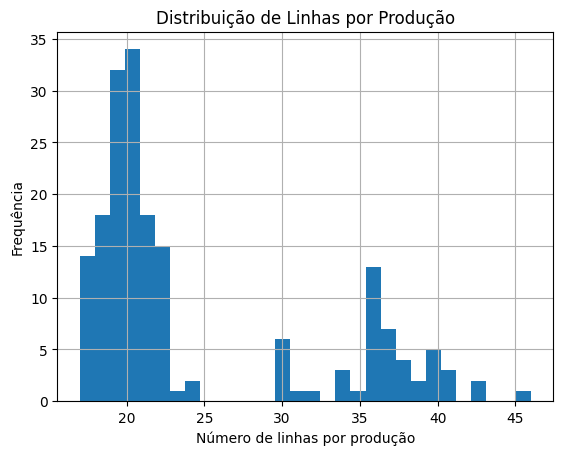

In [ ]:
df_prod = producao_raw.copy()

df_prod['id_producao'] = (
    df_prod['Título da Produção'].str.strip().str.upper() + "_" +
    df_prod['Ano da Produção'].astype(str)
)

linhas_por_producao = df_prod.groupby('id_producao').size()

import matplotlib.pyplot as plt

plt.figure()
linhas_por_producao.hist(bins=30)
plt.title("Distribuição de Linhas por Produção")
plt.xlabel("Número de linhas por produção")
plt.ylabel("Frequência")
plt.show()


## Observa-se que cada produção possui múltiplas linhas associadas.

Formato normalizado da base!

- cada linha representa um atributo ou autor
- e não uma produção única

---

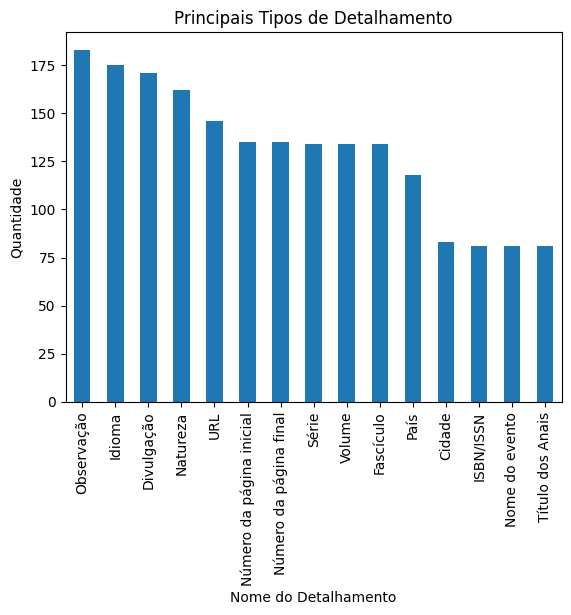

In [ ]:
detalhamento_counts = (
    df_prod['Nome do Detalhamento']
    .value_counts()
    .head(15)
)

plt.figure()
detalhamento_counts.plot.bar()
plt.title("Principais Tipos de Detalhamento")
plt.ylabel("Quantidade")
plt.show()

## Os detalhamentos representam metadados da produção, como:

- ISSN
- DOI
- idioma
- editora

!! Não descartar ISSN, DOI...

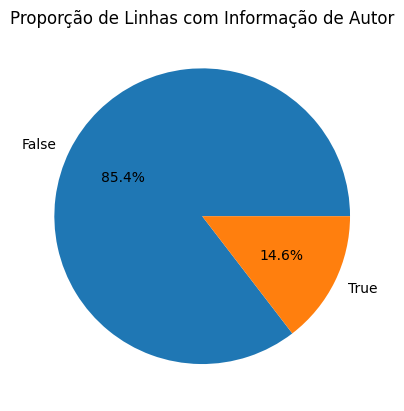

In [ ]:
tem_autor = df_prod['Nome do Autor'].notna()

counts = tem_autor.value_counts()

plt.figure()
counts.plot.pie(autopct='%1.1f%%')
plt.title("Proporção de Linhas com Informação de Autor")
plt.ylabel("")
plt.show()


## Observa-se que nem todas as linhas possuem informação de autoria.

Isso ocorre porque:

- algumas linhas representam apenas detalhamentos da produção

Portanto, é necessário separar:

- dados de autoria
- dados de metadados


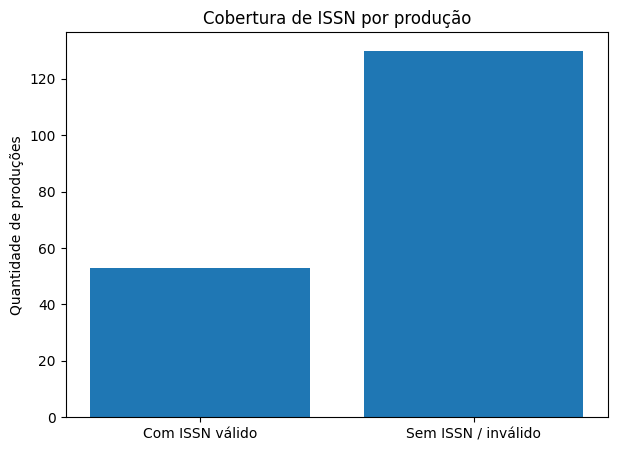

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def extrair_issn(valor):
    if pd.isna(valor):
        return None
    match = re.search(r'\d{4}-\d{3}[\dXx]', str(valor))
    return match.group(0) if match else None

df_prod["id_producao"] = (
    df_prod["Título da Produção"].astype(str).str.strip().str.upper()
    + "_"
    + df_prod["Ano da Produção"].astype(str).str.strip()
)

df_issn_linhas = df_prod[
    df_prod["Nome do Detalhamento"].astype(str).str.strip() == "ISSN / Título do periódico"
].copy()

df_issn_linhas["ISSN"] = df_issn_linhas["Valor do Detalhamento"].apply(extrair_issn)

issn_por_producao = (
    df_issn_linhas.groupby("id_producao")["ISSN"]
    .apply(lambda s: s.dropna().iloc[0] if s.dropna().shape[0] > 0 else None)
    .reset_index()
)

todas_producoes = df_prod[["id_producao"]].drop_duplicates()
cobertura_issn = todas_producoes.merge(issn_por_producao, on="id_producao", how="left")
issn_validos = cobertura_issn["ISSN"].notna().sum()
issn_invalidos_ou_ausentes = cobertura_issn["ISSN"].isna().sum()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Com ISSN válido", "Sem ISSN / inválido"],
    [issn_validos, issn_invalidos_ou_ausentes]
)
plt.title("Cobertura de ISSN por produção")
plt.ylabel("Quantidade de produções")
plt.show()

In [ ]:
import re
import pandas as pd
import numpy as np
df_prod = df_prod.copy()

df_prod["id_producao"] = (
    df_prod["Título da Produção"].astype(str).str.strip().str.upper()
    + "_"
    + df_prod["Ano da Produção"].astype(str).str.strip()
)


def extrair_issn(valor):
    if pd.isna(valor):
        return None
    match = re.search(r"\b\d{4}-\d{3}[\dXx]\b", str(valor))
    return match.group(0).upper() if match else None

def extrair_isbn(valor):
    if pd.isna(valor):
        return None
    texto = str(valor).upper().replace("ISBN", "").strip()
    match = re.search(r"\b(?:97[89][-\s]?)?\d(?:[-\s]?\d){8,16}\b", texto)
    if match:
        return re.sub(r"[\s-]+", "", match.group(0))
    return None

def extrair_doi(valor):
    if pd.isna(valor):
        return None
    texto = str(valor).strip()
    match = re.search(r"(10\.\d{4,9}/[-._;()/:A-Z0-9]+)", texto, flags=re.I)
    return match.group(1).upper() if match else None

def safe_upper(x):
    if pd.isna(x):
        return ""
    return str(x).strip().upper()

df_prod["tipo_norm"] = df_prod["Tipo da Produção"].apply(safe_upper)
df_prod["subtipo_norm"] = df_prod["Subtipo da Produção"].apply(safe_upper)
df_prod["detalhamento_norm"] = df_prod["Nome do Detalhamento"].apply(safe_upper)


def classificar_estrato(tipo, subtipo):
    texto = f"{tipo} | {subtipo}"

    if "ARTIGO EM PERIÓDICO" in texto:
        return "ARTIGO_PERIODICO"

    if "LIVRO" in texto and "CAPÍTULO" not in texto and "CAPITULO" not in texto:
        return "LIVRO"

    if "CAPÍTULO" in texto or "CAPITULO" in texto:
        return "CAPITULO_LIVRO"

    if "ANAIS" in texto or "EVENTO" in texto or "TRABALHO EM EVENTO" in texto:
        return "TRABALHO_EVENTO"

    if "PATENTE" in texto:
        return "PATENTE"

    return "OUTROS"


classificacao_producao = (
    df_prod.groupby("id_producao")[["tipo_norm", "subtipo_norm"]]
    .agg(lambda s: s.dropna().iloc[0] if not s.dropna().empty else "")
    .reset_index()
)

classificacao_producao["estrato_producao"] = classificacao_producao.apply(
    lambda row: classificar_estrato(row["tipo_norm"], row["subtipo_norm"]),
    axis=1
)


df_meta = df_prod.copy()


df_meta["issn_extraido"] = np.where(
    df_meta["detalhamento_norm"].str.contains("ISSN", na=False),
    df_meta["Valor do Detalhamento"].apply(extrair_issn),
    None
)

df_meta["isbn_extraido"] = np.where(
    df_meta["detalhamento_norm"].str.contains("ISBN", na=False),
    df_meta["Valor do Detalhamento"].apply(extrair_isbn),
    None
)

df_meta["doi_extraido"] = np.where(
    df_meta["detalhamento_norm"].str.contains("DOI", na=False),
    df_meta["Valor do Detalhamento"].apply(extrair_doi),
    None
)

def primeiro_valido(serie):
    serie = serie.dropna()
    serie = serie[serie.astype(str).str.strip() != ""]
    return serie.iloc[0] if not serie.empty else None

identificadores_por_producao = (
    df_meta.groupby("id_producao")[["issn_extraido", "isbn_extraido", "doi_extraido"]]
    .agg(primeiro_valido)
    .reset_index()
)


df_estratificado = classificacao_producao.merge(
    identificadores_por_producao,
    on="id_producao",
    how="left"
)


def identificador_esperado(estrato):
    mapa = {
        "ARTIGO_PERIODICO": "ISSN",
        "LIVRO": "ISBN",
        "CAPITULO_LIVRO": "ISBN",
        "TRABALHO_EVENTO": "DOI/ISBN/ISSN",
        "PATENTE": "SEM_IDENT_BIBLIO",
        "OUTROS": "NAO_DEFINIDO"
    }
    return mapa.get(estrato, "NAO_DEFINIDO")

df_estratificado["identificador_esperado"] = df_estratificado["estrato_producao"].apply(identificador_esperado)


def possui_identificador_esperado(row):
    estrato = row["estrato_producao"]

    if estrato == "ARTIGO_PERIODICO":
        return pd.notna(row["issn_extraido"])

    if estrato in ["LIVRO", "CAPITULO_LIVRO"]:
        return pd.notna(row["isbn_extraido"])

    if estrato == "TRABALHO_EVENTO":
        return (
            pd.notna(row["doi_extraido"]) or
            pd.notna(row["isbn_extraido"]) or
            pd.notna(row["issn_extraido"])
        )

    if estrato == "PATENTE":
        return True

    return None  # não avaliado

df_estratificado["possui_identificador_esperado"] = df_estratificado.apply(
    possui_identificador_esperado,
    axis=1
)


resumo_estratos = (
    df_estratificado.groupby("estrato_producao")
    .agg(
        total_producoes=("id_producao", "nunique"),
        com_issn=("issn_extraido", lambda s: s.notna().sum()),
        com_isbn=("isbn_extraido", lambda s: s.notna().sum()),
        com_doi=("doi_extraido", lambda s: s.notna().sum()),
        com_identificador_esperado=("possui_identificador_esperado", lambda s: (s == True).sum()),
        sem_identificador_esperado=("possui_identificador_esperado", lambda s: (s == False).sum())
    )
    .reset_index()
)

resumo_estratos["pct_com_identificador_esperado"] = (
    resumo_estratos["com_identificador_esperado"] / resumo_estratos["total_producoes"] * 100
).round(2)

display(df_estratificado.head(10))
display(resumo_estratos)

,id_producao,tipo_norm,subtipo_norm,estrato_producao,issn_extraido,isbn_extraido,doi_extraido,identificador_esperado,possui_identificador_esperado
0,A DSP BASED INDIRECT FIELD-ORIENTED INDUCTION ...,BIBLIOGRÁFICA,TRABALHO EM ANAIS,TRABALHO_EVENTO,None,None,None,DOI/ISBN/ISSN,False
1,A EXPERIÊNCIA DO PET-UFC NA AMBIENTAÇÃO DE ALU...,BIBLIOGRÁFICA,LIVRO,LIVRO,None,9786525139500,None,ISBN,True
2,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,ARTIGO_PERIODICO,2169-3536,None,10.1109/ACCESS.2021.3074360,ISSN,True
3,A HEURISTIC FOR MIXED INTEGER AND NONLINEAR PR...,BIBLIOGRÁFICA,TRABALHO EM ANAIS,TRABALHO_EVENTO,None,None,None,DOI/ISBN/ISSN,False
4,A PERSPECTIVA DA LEI GERAL DE PROTEÇÃO DE DADO...,BIBLIOGRÁFICA,LIVRO,LIVRO,None,9786553607842,None,ISBN,True
5,A SEMI-DISTRIBUTED APPROACH FOR UPLINK MAX-MIN...,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,ARTIGO_PERIODICO,1980-6604,None,10.14209/JCIS.2021.9,ISSN,True
6,ACTIVE LEARNING METHODOLOGY APPLIED IN ELECTRI...,BIBLIOGRÁFICA,TRABALHO EM ANAIS,TRABALHO_EVENTO,None,None,None,DOI/ISBN/ISSN,False
7,ADAPTABLE TDD SCHEME FOR MOBILE IAB CELLS_2022,TÉCNICA,PATENTE,PATENTE,None,None,None,SEM_IDENT_BIBLIO,True
8,ADAPTIVE POWER ALLOCATION AMONG PRIVATE AND CO...,BIBLIOGRÁFICA,TRABALHO EM ANAIS,TRABALHO_EVENTO,None,None,None,DOI/ISBN/ISSN,False
9,AERIAL RECONFIGURABLE INTELLIGENT SURFACE-AIDE...,BIBLIOGRÁFICA,TRABALHO EM ANAIS,TRABALHO_EVENTO,None,None,None,DOI/ISBN/ISSN,False


,estrato_producao,total_producoes,com_issn,com_isbn,com_doi,com_identificador_esperado,sem_identificador_esperado,pct_com_identificador_esperado
0,ARTIGO_PERIODICO,53,53,0,14,53,0,100.00
1,LIVRO,12,0,12,0,12,0,100.00
2,OUTROS,12,1,0,0,0,0,0.00
3,PATENTE,7,0,0,0,7,0,100.00
4,TRABALHO_EVENTO,99,1,0,0,1,98,1.01


<Figure size 1000x600 with 0 Axes>

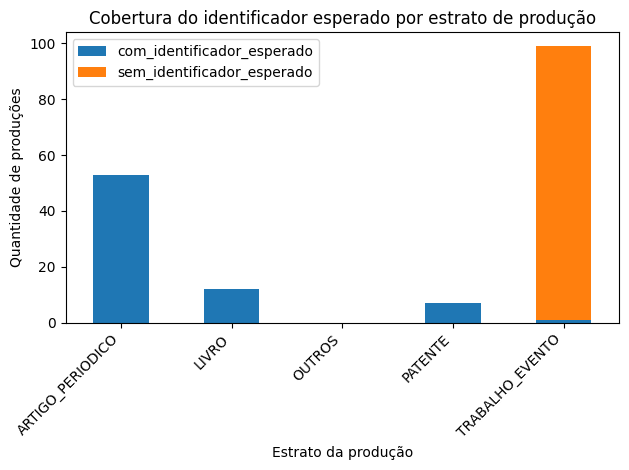

In [ ]:
import matplotlib.pyplot as plt

graf = resumo_estratos.set_index("estrato_producao")[
    ["com_identificador_esperado", "sem_identificador_esperado"]
]

plt.figure(figsize=(10, 6))
graf.plot(kind="bar", stacked=True)
plt.title("Cobertura do identificador esperado por estrato de produção")
plt.xlabel("Estrato da produção")
plt.ylabel("Quantidade de produções")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Nem todos os registros possuem ISSN válido extraível.

Isso impacta diretamente:

- a associação com a base Qualis
- o cálculo dos indicadores DPI e PR


In [ ]:
producao_raw = producao_raw.copy()
dirty_producao = detect_dirty_patterns(producao_raw)

display(producao_raw.head(10))
display(dirty_producao.head(10))

if "Ano da Produção" in producao_raw.columns:
    resumo_por_ano = (
        producao_raw.groupby("Ano da Produção")
        .size()
        .reset_index(name="n_linhas")
        .sort_values("Ano da Produção")
    )
    display(resumo_por_ano)

if "arquivo_origem" in producao_raw.columns:
    resumo_por_arquivo = (
        producao_raw.groupby("arquivo_origem")
        .size()
        .reset_index(name="n_linhas")
        .sort_values("arquivo_origem")
    )
    display(resumo_por_arquivo)

/tmp/ipykernel_276/1805873757.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors="coerce", dayfirst=True).notna().mean() >= threshold
/tmp/ipykernel_276/1805873757.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors="coerce", dayfirst=True).notna().mean() >= threshold
/tmp/ipykernel_276/1805873757.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors="coerce", dayfirst=True).notna().mean() >= threshold
/tmp/ipykernel_276/1805873757.py:23: UserWarning: Could not i

,Calendário,Ano do Calendário,Data-Hora do Envio,Código do PPG,Nome do PPG,Área de Avaliação,IES Sigla,IES Nome,Ano da Produção,Título da Produção,Produção Glosada?,Tipo da Produção,Subtipo da Produção,Área de Concentração,Linha de Pesquisa,Projeto de Pesquisa,Nome do Detalhamento,Valor do Detalhamento,Nome do Autor,Categoria do Autor,Número de Ordem Autor,arquivo_origem,ano_arquivo,aba_producao_origem,arquivo_origem_2024
0,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Cidade,NaN,NaN,NaN,NaN,2021_coleta.xlsx,2021,Produção Intelectual,NaN
1,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Divulgação,MEIO DIGITAL,NaN,NaN,NaN,2021_coleta.xlsx,2021,Produção Intelectual,NaN
2,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Fascículo,NaN,NaN,NaN,NaN,2021_coleta.xlsx,2021,Produção Intelectual,NaN
3,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Idioma,INGLES,NaN,NaN,NaN,2021_coleta.xlsx,2021,Produção Intelectual,NaN
4,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,ISSN / Título do periódico,2169-3536 / (2169-3536) IEEE ACCESS,NaN,NaN,NaN,2021_coleta.xlsx,2021,Produção Intelectual,NaN
5,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Natureza,Completo,NaN,NaN,NaN,2021_coleta.xlsx,2021,Produção Intelectual,NaN
6,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Nome da editora,NaN,NaN,NaN,NaN,2021_coleta.xlsx,2021,Produção Intelectual,NaN
7,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,A FRAMEWORK FOR RADIO RESOURCE ALLOCATION AND ...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,Número da página final,NaN,NaN,NaN,NaN,2021_coleta.xlsx,2021,Produção Intelectual,NaN
8,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,

,coluna,nulos,pct_nulos,espacos_inicio_fim,multiplos_espacos,placeholders_ausencia,datas_invalidas,valores_unicos,coluna_constante,score_sujeira
0,Categoria do Autor,3777,85.43,0,0,3777,0,8,0,5836.36
1,Nome do Autor,3777,85.43,0,0,3777,0,300,0,5836.36
2,arquivo_origem_2024,3548,80.25,0,0,3548,0,1,1,5492.50
3,Valor do Detalhamento,2602,58.86,0,0,2602,0,628,0,4020.72
4,Produção Glosada?,873,19.75,0,0,873,0,1,1,1359.00
5,Data-Hora do Envio,873,19.75,0,0,873,0,3,0,1349.00
6,Calendário,873,19.75,0,0,873,0,3,0,1349.00
7,Projeto de Pesquisa,708,16.01,0,0,708,0,31,0,1094.02
8,Nome do Detalhamento,644,14.57,0,0,644,0,106,0,995.14
9,Área de Concentração,537,12.15,0,0,537,0,2,0,829.80


,Ano da Produção,n_linhas
0,2021,1801
1,2022,780
2,2023,967
3,2024,873


,arquivo_origem,n_linhas
0,2021_coleta.xlsx,1801
1,2022_coleta.xlsx,780
2,2023_coleta.xlsx,967
3,2024_coleta.xlsx,873


## 4. Nova modelagem para o objetivo multianual

A lógica de modelagem continua a mesma, mas agora a estrutura precisa preservar também o contexto temporal e a origem dos dados.

Separamos a aba em três entidades analíticas:

1. **Produções**: uma linha por produção, com metadados principais e colunas de rastreabilidade;
2. **Detalhamentos**: uma linha por produção e detalhamento;
3. **Autorias**: uma linha por produção e autor.

Essa separação permite:
- calcular indicadores por docente;
- comparar anos distintos;
- exportar resultados consolidados e anuais.

In [ ]:
PRODUCAO_CORE_COLS = [
    "Calendário", "Ano do Calendário", "Data-Hora do Envio", "Código do PPG", "Nome do PPG",
    "Área de Avaliação", "IES Sigla", "IES Nome", "Ano da Produção", "Título da Produção",
    "Produção Glosada?", "Tipo da Produção", "Subtipo da Produção", "Área de Concentração",
    "Linha de Pesquisa", "Projeto de Pesquisa", "arquivo_origem", "ano_arquivo", "aba_producao_origem"
]
DETAIL_COL_NAME = "Nome do Detalhamento"
DETAIL_VAL_COL = "Valor do Detalhamento"
AUTHOR_NAME_COL = "Nome do Autor"
AUTHOR_CAT_COL = "Categoria do Autor"
AUTHOR_ORDER_COL = "Número de Ordem Autor"

def assert_columns_exist(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Colunas ausentes: {missing}")

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

def unique_join(series, sep=" | "):
    vals = pd.Series(series).dropna().astype(str).str.strip()
    vals = vals[vals != ""]
    vals = pd.unique(vals)
    return sep.join(vals) if len(vals) else np.nan

def build_production_id(df):
    req = ["Código do PPG", "Ano da Produção", "Título da Produção", "Tipo da Produção", "Subtipo da Produção"]
    assert_columns_exist(df, req)
    out = df.copy()
    out["id_producao"] = (
        out["Código do PPG"].astype(str).str.strip() + "||" +
        out["Ano da Produção"].astype(str).str.strip() + "||" +
        out["Título da Produção"].astype(str).str.upper().str.strip() + "||" +
        out["Tipo da Produção"].astype(str).str.upper().str.strip() + "||" +
        out["Subtipo da Produção"].astype(str).str.upper().str.strip()
    )
    return out

def extract_issn(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"\b\d{4}-\d{3}[\dXx]\b", str(value))
    return match.group(0).upper() if match else np.nan

def normalize_issn(value):
    if pd.isna(value):
        return np.nan
    text = str(value).upper().strip()
    match = re.search(r"\b\d{4}-\d{3}[\dX]\b", text)
    return match.group(0) if match else np.nan

def split_production_entities(df):
    df = build_production_id(df)
    core_cols = [c for c in PRODUCAO_CORE_COLS if c in df.columns]

    producoes_base = (
        df[["id_producao"] + core_cols]
          .groupby("id_producao", as_index=False)
          .agg({c: first_non_null for c in core_cols})
    )

    assert_columns_exist(df, [DETAIL_COL_NAME, DETAIL_VAL_COL, AUTHOR_NAME_COL, AUTHOR_CAT_COL, AUTHOR_ORDER_COL])

    detalhamentos_base = (
        df[["id_producao", DETAIL_COL_NAME, DETAIL_VAL_COL]]
        .dropna(subset=[DETAIL_COL_NAME, DETAIL_VAL_COL], how="all")
        .copy()
    )

    autorias_base = (
        df[["id_producao", AUTHOR_NAME_COL, AUTHOR_CAT_COL, AUTHOR_ORDER_COL]]
        .dropna(subset=[AUTHOR_NAME_COL], how="all")
        .copy()
    )
    return producoes_base, detalhamentos_base, autorias_base

def pivot_detalhamentos(detalhamentos_base):
    work = detalhamentos_base.copy()
    work[DETAIL_COL_NAME] = work[DETAIL_COL_NAME].astype(str).str.strip()
    detalhe_pivot = (
        work.groupby(["id_producao", DETAIL_COL_NAME], as_index=False)[DETAIL_VAL_COL]
            .agg(unique_join)
            .pivot(index="id_producao", columns=DETAIL_COL_NAME, values=DETAIL_VAL_COL)
            .reset_index()
    )
    detalhe_pivot.columns.name = None
    if "ISSN / Título do periódico" in detalhe_pivot.columns:
        detalhe_pivot["ISSN_extraido"] = detalhe_pivot["ISSN / Título do periódico"].apply(extract_issn)
    else:
        detalhe_pivot["ISSN_extraido"] = np.nan
    return detalhe_pivot

def classify_docente(series_categoria):
    return series_categoria.astype(str).str.lower().str.contains("docente", na=False)

def prepare_authorship_base(autorias_base):
    out = autorias_base.copy()
    out[AUTHOR_NAME_COL] = out[AUTHOR_NAME_COL].map(normalize_text)
    out[AUTHOR_CAT_COL] = out[AUTHOR_CAT_COL].map(normalize_text)
    out[AUTHOR_ORDER_COL] = pd.to_numeric(out[AUTHOR_ORDER_COL], errors="coerce").astype("Int64")
    out["is_docente"] = classify_docente(out[AUTHOR_CAT_COL].fillna(""))
    return out

producoes_base, detalhamentos_base, autorias_base = split_production_entities(producao_raw)
detalhe_pivot = pivot_detalhamentos(detalhamentos_base)
autorias_prepared = prepare_authorship_base(autorias_base)

import ipywidgets as widgets
from IPython.display import display


out1 = widgets.Output(); out2 = widgets.Output(); out3 = widgets.Output()

with out1: display(producoes_base.head(3))
with out2: display(detalhamentos_base.head())
with out3: display(autorias_prepared.head(3))


tabs = widgets.Tab(children=[out1, out2, out3])
tabs.set_title(0, 'Produções')
tabs.set_title(1, 'Detalhamentos')
tabs.set_title(2, 'Autorias')

display(tabs)

## 5. Evidência do problema de granularidade

Aqui mostramos por que o agrupamento precisa ter cuidado: uma mesma produção pode ter:
- vários autores;
- vários detalhamentos;
- e a relação entre os dois não pode ser perdida.

In [ ]:
autores_por_prod = (
    autorias_prepared.groupby("id_producao", as_index=False)
    .agg(n_autores=(AUTHOR_NAME_COL, "count"),
         n_docentes_autores=("is_docente", "sum"))
)

detalhes_por_prod = (
    detalhamentos_base.groupby("id_producao", as_index=False)
    .agg(n_detalhamentos=(DETAIL_COL_NAME, "count"),
         n_tipos_detalhe=(DETAIL_COL_NAME, "nunique"))
)

granularidade_diag = (
    producoes_base[["id_producao", "Título da Produção", "Ano da Produção"]]
    .merge(autores_por_prod, on="id_producao", how="left")
    .merge(detalhes_por_prod, on="id_producao", how="left")
)

display(granularidade_diag.sort_values(["n_autores", "n_tipos_detalhe"], ascending=False).head(5))

,id_producao,Título da Produção,Ano da Produção,n_autores,n_docentes_autores,n_detalhamentos,n_tipos_detalhe
102,22001018081P2||2023||A EXPERIÊNCIA DO PET-UFC ...,A EXPERIÊNCIA DO PET-UFC NA AMBIENTAÇÃO DE ALU...,2023,9,1,37,37
41,"22001018081P2||2021||METHODS, RADIO NETWORK NO...","METHODS, RADIO NETWORK NODE AND NETWORK NODE F...",2021,8,1,32,32
32,22001018081P2||2021||IRS-ASSISTED MASSIVE MIMO...,IRS-ASSISTED MASSIVE MIMO-NOMA NETWORKS WITH P...,2021,8,2,16,16
138,22001018081P2||2023||SYSTEM LEVEL EVALUATION O...,SYSTEM LEVEL EVALUATION OF NETWORK-CONTROLLED ...,2023,8,1,16,16
61,22001018081P2||2021||TENSOR-BASED LEARNING FRA...,TENSOR-BASED LEARNING FRAMEWORK FOR AUTOMATIC ...,2021,8,1,15,15


## 6. Preparação da planilha Qualis e correlação com a produção

O merge principal é feito via ISSN.  
Isso exige uma limpeza específica: extrair o ISSN do campo textual do detalhamento.

In [ ]:
def prepare_qualis_table(qualis_df):
    df = qualis_df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    col_map = {}
    for c in df.columns:
        c_norm = snake_case(c)
        if "issn" in c_norm and "titulo" not in c_norm:
            col_map["ISSN"] = c
        elif ("titulo" in c_norm or "revista" in c_norm or "periodico" in c_norm):
            col_map["TITULO_REVISTA"] = c
        elif "qualis" in c_norm:
            col_map["QUALIS"] = c

    if "ISSN" not in col_map:
        col_map["ISSN"] = df.columns[0]
    if "TITULO_REVISTA" not in col_map:
        col_map["TITULO_REVISTA"] = df.columns[1]
    if "QUALIS" not in col_map:
        col_map["QUALIS"] = df.columns[2]

    out = df[[col_map["ISSN"], col_map["TITULO_REVISTA"], col_map["QUALIS"]]].copy()
    out.columns = ["ISSN", "TITULO_REVISTA", "QUALIS"]

    out["ISSN"] = out["ISSN"].apply(normalize_issn)
    out["TITULO_REVISTA"] = out["TITULO_REVISTA"].map(normalize_text)
    out["QUALIS"] = out["QUALIS"].astype(str).str.upper().str.strip()

    validos = {"A1", "A2", "A3", "A4", "B1", "B2", "B3", "B4"}
    out["QUALIS_VALIDO"] = out["QUALIS"].where(out["QUALIS"].isin(validos), np.nan)

    out = out.dropna(subset=["ISSN"]).drop_duplicates(subset=["ISSN"], keep="first").reset_index(drop=True)
    return out

def enrich_productions_with_qualis(producoes_base, detalhe_pivot, qualis_prepared):
    out = producoes_base.merge(detalhe_pivot, on="id_producao", how="left")
    out["ISSN"] = out["ISSN_extraido"].apply(normalize_issn)
    out = out.merge(
        qualis_prepared[["ISSN", "TITULO_REVISTA", "QUALIS_VALIDO"]],
        on="ISSN",
        how="left"
    )
    out = out.rename(columns={"TITULO_REVISTA": "TITULO_REVISTA_QUALIS", "QUALIS_VALIDO": "QUALIS"})
    out["tem_issn"] = out["ISSN"].notna()
    out["tem_qualis"] = out["QUALIS"].notna()
    return out

qualis_prepared = prepare_qualis_table(qualis_std)
producoes_enriquecidas = enrich_productions_with_qualis(producoes_base, detalhe_pivot, qualis_prepared)

out1 = widgets.Output(); out2 = widgets.Output();

with out1: display(qualis_prepared.head())
with out2: display(producoes_enriquecidas[["id_producao", "Título da Produção", "ISSN", "QUALIS", "ISSN / Título do periódico"]].head(10))



tabs = widgets.Tab(children=[out1, out2])
tabs.set_title(0, 'Qualis')
tabs.set_title(1, 'Detalhamento')
display(tabs)


## 7. Regras do cálculo dos indicadores

### Pesos Qualis
- A1 = 1.00
- A2 = 0.875
- A3 = 0.75
- A4 = 0.60
- B1 = 0.30
- B2 = 0.20
- B3 = 0.10
- B4 = 0.05

### Lógica adotada neste notebook
O cálculo abaixo produz duas camadas de resultado:

1. **Visão consolidada do período**: combina 2021, 2022 e 2023 em uma única leitura;
2. **Visão anual**: recalcula os indicadores separadamente por `Ano da Produção`.

### Observação metodológica
- `DPI_programa` é mostrado como a pontuação total do programa dividida por `DP`;
- `PR_programa` é mostrado como a soma dos créditos distribuídos entre docentes autores do PPGEEC;
- o denominador `DP` pode ser informado manualmente, se houver valor oficial por ano ou no consolidado.

In [ ]:
QUALIS_WEIGHTS = {
    "A1": 1.00, "A2": 0.875, "A3": 0.75, "A4": 0.60,
    "B1": 0.30, "B2": 0.20, "B3": 0.10, "B4": 0.05
}

def qualis_score(qualis):
    if pd.isna(qualis):
        return 0.0
    return float(QUALIS_WEIGHTS.get(str(qualis).upper().strip(), 0.0))

def add_indicator_inputs(producoes_enriquecidas_df, autorias_prepared_df, dp_docentes=None):
    prod = producoes_enriquecidas_df.copy()
    aut = autorias_prepared_df.copy()

    prod["Ano da Produção"] = pd.to_numeric(prod["Ano da Produção"], errors="coerce").astype("Int64")
    prod["pontuacao_qualis"] = prod["QUALIS"].apply(qualis_score)
    prod["fator_aderencia"] = 1.0
    prod["pontuacao_pr_base"] = prod["pontuacao_qualis"] * prod["fator_aderencia"]

    docentes_por_prod = (
        aut[aut["is_docente"]]
        .groupby("id_producao", as_index=False)
        .agg(n_docentes_autores=(AUTHOR_NAME_COL, "nunique"))
    )

    prod = prod.merge(docentes_por_prod, on="id_producao", how="left")
    prod["n_docentes_autores"] = prod["n_docentes_autores"].fillna(0).astype(int)

    docentes_distintos = aut.loc[aut["is_docente"], AUTHOR_NAME_COL].dropna().nunique()
    dp = dp_docentes if dp_docentes is not None else docentes_distintos
    return prod, aut, int(dp)

def build_docente_indicators(autorias_docentes_df, dp):
    estratos_por_docente = (
        autorias_docentes_df.groupby([AUTHOR_NAME_COL, "QUALIS"], dropna=False)
        .size().reset_index(name="n_publicacoes")
    )
    estratos_wide = (
        estratos_por_docente
        .assign(QUALIS=lambda x: x["QUALIS"].fillna("SEM_QUALIS"))
        .pivot(index=AUTHOR_NAME_COL, columns="QUALIS", values="n_publicacoes")
        .fillna(0).reset_index()
    )
    for estrato in ["A1", "A2", "A3", "A4", "B1", "B2", "B3", "B4", "SEM_QUALIS"]:
        if estrato not in estratos_wide.columns:
            estratos_wide[estrato] = 0

    indicadores_doc = (
        autorias_docentes_df.groupby(AUTHOR_NAME_COL, as_index=False)
        .agg(
            n_producoes=("id_producao", "nunique"),
            pontuacao_total=("credito_dpi_docente", "sum"),
            pr_docente=("credito_pr_docente", "sum")
        )
        .merge(estratos_wide, on=AUTHOR_NAME_COL, how="left")
        .sort_values("pontuacao_total", ascending=False)
        .reset_index(drop=True)
    )
    indicadores_doc["dpi_docente_normalizado"] = indicadores_doc["pontuacao_total"] / dp if dp else np.nan
    return indicadores_doc

def build_program_indicators(producoes_indicadores_df, autorias_docentes_df, dp):
    return pd.DataFrame([{
        "DP": dp,
        "n_docentes_com_producao": autorias_docentes_df[AUTHOR_NAME_COL].nunique(),
        "n_producoes_com_autoria_docente": autorias_docentes_df["id_producao"].nunique(),
        "pontuacao_total_programa": round(float(autorias_docentes_df["credito_dpi_docente"].sum()), 4),
        "DPI_programa": round(float(producoes_indicadores_df["pontuacao_qualis"].sum() / dp), 4) if dp else np.nan,
        "PR_programa": round(float(autorias_docentes_df["credito_pr_docente"].sum()), 4)
    }])

DP_DOCENTES_OFICIAL = None
DP_DOCENTES_POR_ANO = {}

producoes_indicadores, autorias_indicadores, DP = add_indicator_inputs(
    producoes_enriquecidas, autorias_prepared, dp_docentes=DP_DOCENTES_OFICIAL
)

autorias_com_prod = autorias_indicadores.merge(
    producoes_indicadores[
        ["id_producao", "Título da Produção", "Ano da Produção", "Tipo da Produção",
         "Subtipo da Produção", "QUALIS", "pontuacao_qualis", "pontuacao_pr_base", "n_docentes_autores"]
    ],
    on="id_producao",
    how="left"
)

autorias_docentes = autorias_com_prod[autorias_com_prod["is_docente"]].copy()

autorias_docentes["credito_pr_docente"] = np.where(
    autorias_docentes["n_docentes_autores"] > 0,
    autorias_docentes["pontuacao_pr_base"] / autorias_docentes["n_docentes_autores"],
    0.0
)
autorias_docentes["credito_dpi_docente"] = autorias_docentes["pontuacao_qualis"].fillna(0.0)

# visão consolidada do período
indicadores_docente = build_docente_indicators(autorias_docentes, DP)
indicadores_programa = build_program_indicators(producoes_indicadores, autorias_docentes, DP)

# visão por ano
indicadores_docente_ano_list = []
indicadores_programa_ano_list = []

anos_disponiveis = (
    producoes_indicadores["Ano da Produção"]
    .dropna()
    .astype(int)
    .sort_values()
    .unique()
)

for ano in anos_disponiveis:
    prod_ano = producoes_indicadores[producoes_indicadores["Ano da Produção"].astype("Int64") == ano].copy()
    aut_ano = autorias_docentes[autorias_docentes["Ano da Produção"].astype("Int64") == ano].copy()

    dp_ano = DP_DOCENTES_POR_ANO.get(int(ano), aut_ano[AUTHOR_NAME_COL].dropna().nunique())
    ind_doc_ano = build_docente_indicators(aut_ano, dp_ano)
    ind_doc_ano["Ano da Produção"] = int(ano)

    ind_prog_ano = build_program_indicators(prod_ano, aut_ano, dp_ano)
    ind_prog_ano["Ano da Produção"] = int(ano)

    indicadores_docente_ano_list.append(ind_doc_ano)
    indicadores_programa_ano_list.append(ind_prog_ano)

indicadores_docente_ano = (
    pd.concat(indicadores_docente_ano_list, ignore_index=True)
    if indicadores_docente_ano_list else pd.DataFrame()
)
indicadores_programa_ano = (
    pd.concat(indicadores_programa_ano_list, ignore_index=True)
    if indicadores_programa_ano_list else pd.DataFrame()
)

out1 = widgets.Output(); out2 = widgets.Output(); out3 = widgets.Output(); out4 = widgets.Output()

with out1: display(indicadores_docente.head(30))
with out2: display(indicadores_programa)
with out3: display(indicadores_docente_ano.head(30))
with out4: display(indicadores_programa_ano)

tabs = widgets.Tab(children=[out1, out2, out3, out4])
tabs.set_title(0, 'Docentes (consolidado)')
tabs.set_title(1, 'Programa (consolidado)')
tabs.set_title(2, 'Docentes por ano')
tabs.set_title(3, 'Programa por ano')
display(tabs)

## 8. Tabelas de auditoria

Essas tabelas justificam tecnicamente os resultados em duas escalas:

- **consolidada**, para o período inteiro;
- **anual**, para mostrar diferenças de cobertura e classificação entre 2021, 2022 e 2023.

As auditorias centrais continuam sendo:
- produções sem ISSN;
- produções com ISSN, mas sem correspondência Qualis;
- cobertura geral do enriquecimento;
- distribuição dos estratos por ano.

In [ ]:
producoes_sem_issn = producoes_indicadores[producoes_indicadores["ISSN"].isna()].copy()
producoes_com_issn_sem_qualis = producoes_indicadores[
    producoes_indicadores["ISSN"].notna() & producoes_indicadores["QUALIS"].isna()
].copy()

resumo_estratos = (
    producoes_indicadores["QUALIS"].fillna("SEM_QUALIS")
    .value_counts(dropna=False)
    .rename_axis("estrato")
    .reset_index(name="n_producoes")
)

cobertura_qualis = pd.DataFrame({
    "indicador": ["Produções totais", "Com ISSN", "Com Qualis"],
    "valor": [
        len(producoes_indicadores),
        int(producoes_indicadores["tem_issn"].sum()),
        int(producoes_indicadores["tem_qualis"].sum())
    ]
})

cobertura_qualis_ano = (
    producoes_indicadores.assign(
        Ano_da_Producao=lambda x: x["Ano da Produção"].astype("Int64")
    )
    .groupby("Ano_da_Producao", as_index=False)
    .agg(
        producoes_totais=("id_producao", "nunique"),
        com_issn=("tem_issn", "sum"),
        com_qualis=("tem_qualis", "sum")
    )
    .rename(columns={"Ano_da_Producao": "Ano da Produção"})
)

resumo_estratos_ano = (
    producoes_indicadores.assign(
        estrato=lambda x: x["QUALIS"].fillna("SEM_QUALIS"),
        Ano_da_Producao=lambda x: x["Ano da Produção"].astype("Int64")
    )
    .groupby(["Ano_da_Producao", "estrato"], as_index=False)
    .size()
    .rename(columns={"Ano_da_Producao": "Ano da Produção", "size": "n_producoes"})
)

display(cobertura_qualis)
display(cobertura_qualis_ano)

,indicador,valor
0,Produções totais,183
1,Com ISSN,53
2,Com Qualis,46


,Ano da Produção,producoes_totais,com_issn,com_qualis
0,2021,68,27,26
1,2022,34,12,8
2,2023,42,7,7
3,2024,39,7,5


In [ ]:
display(resumo_estratos)


,estrato,n_producoes
0,SEM_QUALIS,137
1,A1,18
2,A3,14
3,A4,8
4,A2,3
5,B4,1
6,B1,1
7,B3,1


In [ ]:
display(producoes_sem_issn.head(20))


,id_producao,Calendário,Ano do Calendário,Data-Hora do Envio,Código do PPG,Nome do PPG,Área de Avaliação,IES Sigla,IES Nome,Ano da Produção,Título da Produção,Produção Glosada?,Tipo da Produção,Subtipo da Produção,Área de Concentração,Linha de Pesquisa,Projeto de Pesquisa,arquivo_origem,ano_arquivo,aba_producao_origem,(PTT) Abragência Territorial,(PTT) Abrangência Territorial,(PTT) Anexo,(PTT) Complexidade,(PTT) Correspondência com os novos subtipos-produtos técnicos/tecnológicos,(PTT) Código do Registro,(PTT) Código do registro,(PTT) Declaração de vínculo do produto com PDI da Instituição,(PTT) Descrição do tipo de Impacto,(PTT) Estágio da Tecnologia,(PTT) Finalidade,(PTT) Houve fomento?,(PTT) Há registro/depósito de propriedade intelectual?,(PTT) Há transferência de tecnologia/conhecimento?,(PTT) Impacto - Demanda,(PTT) Impacto - Nível,(PTT) Impacto - Objetivo da Pesquisa,(PTT) Impacto - Tipo,(PTT) Impacto - Área impactada pela produção,(PTT) Inovação,(PTT) Replicabilidade,(PTT) Setor da sociedade beneficiado pelo impacto,(PTT) URL,Ano Desenvolvimento,Ano da Primeira Edição,Arquivo,Catálogo,Cidade,Cidade / País,Cidade da Editora,Cidade do evento,Conselho Editorial,Data,Data da Indicação,Data da Premiação,Data de Concessão,Data do Depósito,Data do Pedido de Depósito,Data do Pedido de Exame,Disponibilidade,Distribuição e Acesso,Divulgação,Duração,Edição / Número,Especificar outra natureza do texto,Especificar outros leitores preferenciais,Estrato Informado,Evento,Fascículo,Financiador,Financiamento,ISBN,ISBN/ISSN,ISSN,ISSN / Título do periódico,Idioma,Indicação como Obra de Referência,Informações Sobre Autores,Instituição Promotora,Instituição do Depósito,Instituição financiadora,Instituição promotora,Instituição promotora ou evento,Itinerante,Leitor preferencial,Local,Meio de Divulgação,Natureza,Natureza da Obra,Natureza do Conteúdo,Natureza do texto,Nome da Instituição,Nome da Instituição da Premiação,Nome da editora,Nome do Financiador,Nome do evento,Nível,Número da página final,Número da página inicial,Número de Páginas da Contribuição na Obra,Número de páginas,Número de páginas da Obra,Número do DOI,Observação,Origem da obra,Parecer e Revisão por Pares,Participação dos autores,País,Premiação,Reedição,Reimpressão,Série,Tipo,Tipo da Contribuição na Obra,Tipo de Editora,Tiragem,Tradução da obra para outros idiomas,Título,Título da Obra,Título do jornal ou revista,Título dos Anais,Título em Inglês,URL,URL do DOI,Volume,Índice Remissivo,ISSN_extraido,TITULO_REVISTA_QUALIS,QUALIS,tem_issn,tem_qualis,pontuacao_qualis,fator_aderencia,pontuacao_pr_base,n_docentes_autores
2,22001018081P2||2021||AERIAL RECONFIGURABLE INT...,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,AERIAL RECONFIGURABLE INTELLIGENT SURFACE-AIDE...,Não,BIBLIOGRÁFICA,TRABALHO EM ANAIS,SISTEMAS DE INFORMAÇÃO,SISTEMAS DE COMUNICAÇÃO,Técnicas Emergentes para Sistemas de Comunicações,2021_coleta.xlsx,2021,Produção Intelectual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Virtual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MEIO DIGITAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INGLES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRABALHO COMPLETO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"IEEE International Symposium on Personal, Indo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Estados Unidos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PIMRC'21,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,False,False,0.0,1.0,0.0,1
4,22001018081P2||2021||ANÁLISE COMPARATIVA DA IN...,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,ANÁLISE COMPARATIVA DA INFLUÊNCIA DE OTIMIZADO...,Não,BIBLIOGRÁFICA,TRABALHO EM ANAIS,SISTEMAS DE INFORMAÇÃO,ALGORITMOS E COMPUTAÇÃO DISTRIBUÍDA,Análise de Imagens Termográficas para a Cla

In [ ]:
display(producoes_com_issn_sem_qualis.head(20))

,id_producao,Calendário,Ano do Calendário,Data-Hora do Envio,Código do PPG,Nome do PPG,Área de Avaliação,IES Sigla,IES Nome,Ano da Produção,Título da Produção,Produção Glosada?,Tipo da Produção,Subtipo da Produção,Área de Concentração,Linha de Pesquisa,Projeto de Pesquisa,arquivo_origem,ano_arquivo,aba_producao_origem,(PTT) Abragência Territorial,(PTT) Abrangência Territorial,(PTT) Anexo,(PTT) Complexidade,(PTT) Correspondência com os novos subtipos-produtos técnicos/tecnológicos,(PTT) Código do Registro,(PTT) Código do registro,(PTT) Declaração de vínculo do produto com PDI da Instituição,(PTT) Descrição do tipo de Impacto,(PTT) Estágio da Tecnologia,(PTT) Finalidade,(PTT) Houve fomento?,(PTT) Há registro/depósito de propriedade intelectual?,(PTT) Há transferência de tecnologia/conhecimento?,(PTT) Impacto - Demanda,(PTT) Impacto - Nível,(PTT) Impacto - Objetivo da Pesquisa,(PTT) Impacto - Tipo,(PTT) Impacto - Área impactada pela produção,(PTT) Inovação,(PTT) Replicabilidade,(PTT) Setor da sociedade beneficiado pelo impacto,(PTT) URL,Ano Desenvolvimento,Ano da Primeira Edição,Arquivo,Catálogo,Cidade,Cidade / País,Cidade da Editora,Cidade do evento,Conselho Editorial,Data,Data da Indicação,Data da Premiação,Data de Concessão,Data do Depósito,Data do Pedido de Depósito,Data do Pedido de Exame,Disponibilidade,Distribuição e Acesso,Divulgação,Duração,Edição / Número,Especificar outra natureza do texto,Especificar outros leitores preferenciais,Estrato Informado,Evento,Fascículo,Financiador,Financiamento,ISBN,ISBN/ISSN,ISSN,ISSN / Título do periódico,Idioma,Indicação como Obra de Referência,Informações Sobre Autores,Instituição Promotora,Instituição do Depósito,Instituição financiadora,Instituição promotora,Instituição promotora ou evento,Itinerante,Leitor preferencial,Local,Meio de Divulgação,Natureza,Natureza da Obra,Natureza do Conteúdo,Natureza do texto,Nome da Instituição,Nome da Instituição da Premiação,Nome da editora,Nome do Financiador,Nome do evento,Nível,Número da página final,Número da página inicial,Número de Páginas da Contribuição na Obra,Número de páginas,Número de páginas da Obra,Número do DOI,Observação,Origem da obra,Parecer e Revisão por Pares,Participação dos autores,País,Premiação,Reedição,Reimpressão,Série,Tipo,Tipo da Contribuição na Obra,Tipo de Editora,Tiragem,Tradução da obra para outros idiomas,Título,Título da Obra,Título do jornal ou revista,Título dos Anais,Título em Inglês,URL,URL do DOI,Volume,Índice Remissivo,ISSN_extraido,TITULO_REVISTA_QUALIS,QUALIS,tem_issn,tem_qualis,pontuacao_qualis,fator_aderencia,pontuacao_pr_base,n_docentes_autores
43,22001018081P2||2021||MÉTODOS DE RASTREIO DO PO...,Coleta de Informações 2021,2021.0,30/03/2023 - 15:07,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2021,MÉTODOS DE RASTREIO DO PONTO DE MÁXIMA POTÊNCI...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE ENERGIA ELÉTRICA,ELETRÔNICA DE POTÊNCIA,Aplicações de Eletrônica de Potência em Sistem...,2021_coleta.xlsx,2021,Produção Intelectual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MEIO DIGITAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2525-8761,2525-8761 / (2525-8761) BRAZILIAN JOURNAL OF D...,PORTUGUES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Completo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33739,33714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,2525-8761,BRAZILIAN JOURNAL OF DEVELOPMENT,NaN,True,False,0.0,1.0,0.0,2
77,22001018081P2||2022||DEVELOPMENT OF A DIDACTIC...,Coleta de Informações 2022,2022.0,25/05/2023 - 13:22,22001018081P2,Engenharia Elétrica e de Computação,ENGENHARIAS IV,UFC,UNIVERSIDADE FEDERAL DO CEARÁ,2022,DEVELOPMENT OF A DIDACTIC PROTOTYPE OF A QUADB...,Não,BIBLIOGRÁFICA,ARTIGO EM PERIÓDICO,SISTEMAS DE ENERGIA ELÉTRICA,ELETRÔNICA DE POTÊNCIA,Controle Robusto aplicado

## 9. Gráficos explicativos

Os gráficos abaixo foram escolhidos para responder quatro perguntas:

1. o dado está suficientemente preparado para cálculo?
2. qual é a cobertura de ISSN e Qualis no consolidado?
3. como a distribuição dos estratos e dos indicadores varia por ano?
4. quais docentes concentram maior pontuação no consolidado e em cada ano?

In [ ]:

AUTHOR_NAME_COL = "Nome do Autor"

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_current_fig(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


out1, out2, out3, out4, out5, out6, out7 = [widgets.Output() for _ in range(7)]

# TAB 1: Cobertura
with out1:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(cobertura_qualis["indicador"], cobertura_qualis["valor"], color='skyblue')
    plt.gca().bar_label(bars, padding=3)
    plt.title("Cobertura do enriquecimento com ISSN e Qualis")
    save_current_fig("grafico_cobertura.png")

# TAB 2: Qualis
with out2:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(resumo_estratos["estrato"], resumo_estratos["n_producoes"], color='salmon')
    plt.gca().bar_label(bars, padding=3)
    plt.title("Distribuição por estrato Qualis")
    save_current_fig("grafico_qualis.png")

# TAB 3: Ranking DPI (Corrigido para evitar KeyError)
with out3:
    if AUTHOR_NAME_COL in indicadores_docente.columns:
        top_docentes = indicadores_docente.head(20).copy()
        plt.figure(figsize=(10, max(5, len(top_docentes) * 0.35)))
        bars = plt.barh(top_docentes[AUTHOR_NAME_COL], top_docentes["pontuacao_total"], color='teal')
        plt.gca().invert_yaxis()
        plt.gca().bar_label(bars, padding=5, fmt='%.1f')
        plt.title("Ranking de docentes por pontuação")
        save_current_fig("ranking_dpi.png")
    else:
        print(f"Erro: A coluna '{AUTHOR_NAME_COL}' não foi encontrada em indicadores_docente.")
        print(f"Colunas disponíveis: {list(indicadores_docente.columns)}")

# TAB 4: Ranking PR
with out4:
    if AUTHOR_NAME_COL in indicadores_docente.columns:
        top_pr = indicadores_docente.sort_values("pr_docente", ascending=False).head(20).copy()
        plt.figure(figsize=(10, max(5, len(top_pr) * 0.35)))
        bars = plt.barh(top_pr[AUTHOR_NAME_COL], top_pr["pr_docente"], color='orange')
        plt.gca().invert_yaxis()
        plt.gca().bar_label(bars, padding=5, fmt='%.2f')
        plt.title("Ranking de docentes por PR")
        save_current_fig("ranking_pr.png")
    else:
        print(f"Erro: A coluna '{AUTHOR_NAME_COL}' não encontrada.")

# TAB 5: Status Qualis
with out5:
    qualis_flag = pd.DataFrame({
        "status": ["Com Qualis", "Sem Qualis"],
        "valor": [int(producoes_indicadores["QUALIS"].notna().sum()), int(producoes_indicadores["QUALIS"].isna().sum())]
    })
    plt.figure(figsize=(7, 5))
    bars = plt.bar(qualis_flag["status"], qualis_flag["valor"], color=['green', 'red'])
    plt.gca().bar_label(bars, padding=3)
    plt.title("Produções com e sem Qualis")
    save_current_fig("status_qualis.png")

# TAB 6: Por Ano
with out6:
    graf_ano = cobertura_qualis_ano.set_index("Ano da Produção")[["producoes_totais", "com_issn", "com_qualis"]]
    ax = graf_ano.plot(kind="bar", figsize=(12, 6), width=0.8)
    for container in ax.containers:
        ax.bar_label(container, padding=2, fontsize=8)
    plt.title("Cobertura por ano")
    save_current_fig("cobertura_ano.png")

# TAB 7: Evolução
with out7:
    if not indicadores_programa_ano.empty:
        base_prog = indicadores_programa_ano.sort_values("Ano da Produção")
        plt.figure(figsize=(9, 5))
        plt.plot(base_prog["Ano da Produção"], base_prog["DPI_programa"], marker="o", label="DPI")
        plt.plot(base_prog["Ano da Produção"], base_prog["PR_programa"], marker="o", label="PR")
        plt.title("Evolução anual de DPI e PR")
        plt.legend()
        save_current_fig("evolucao_anual.png")


abas = widgets.Tab(children=[out1, out2, out3, out4, out5, out6, out7])
titulos = ["Cobertura", "Qualis", "Ranking DPI", "Ranking PR", "Status", "Por Ano", "Evolução"]
for i, t in enumerate(titulos): abas.set_title(i, t)
display(abas)

## 10. Exportação

Esta etapa salva:
- bases intermediárias da modelagem;
- indicadores consolidados;
- indicadores por ano;
- tabelas de auditoria;
- gráficos gerados ao longo da análise.

O objetivo é deixar o notebook reutilizável para novos ciclos de coleta, bastando atualizar `EXCEL_PATHS` e a planilha Qualis.

In [ ]:
producoes_base.to_csv(OUTPUT_DIR / "producoes_base.csv", index=False, encoding="utf-8-sig")
detalhamentos_base.to_csv(OUTPUT_DIR / "detalhamentos_base.csv", index=False, encoding="utf-8-sig")
autorias_base.to_csv(OUTPUT_DIR / "autorias_base.csv", index=False, encoding="utf-8-sig")
producoes_indicadores.to_csv(OUTPUT_DIR / "producoes_indicadores.csv", index=False, encoding="utf-8-sig")
indicadores_docente.to_csv(OUTPUT_DIR / "indicadores_docente_consolidado.csv", index=False, encoding="utf-8-sig")
indicadores_programa.to_csv(OUTPUT_DIR / "indicadores_programa_consolidado.csv", index=False, encoding="utf-8-sig")
indicadores_docente_ano.to_csv(OUTPUT_DIR / "indicadores_docente_por_ano.csv", index=False, encoding="utf-8-sig")
indicadores_programa_ano.to_csv(OUTPUT_DIR / "indicadores_programa_por_ano.csv", index=False, encoding="utf-8-sig")
resumo_estratos.to_csv(OUTPUT_DIR / "resumo_estratos_consolidado.csv", index=False, encoding="utf-8-sig")
resumo_estratos_ano.to_csv(OUTPUT_DIR / "resumo_estratos_por_ano.csv", index=False, encoding="utf-8-sig")
cobertura_qualis.to_csv(OUTPUT_DIR / "cobertura_qualis_consolidado.csv", index=False, encoding="utf-8-sig")
cobertura_qualis_ano.to_csv(OUTPUT_DIR / "cobertura_qualis_por_ano.csv", index=False, encoding="utf-8-sig")
granularidade_diag.to_csv(OUTPUT_DIR / "diagnostico_granularidade.csv", index=False, encoding="utf-8-sig")
producoes_sem_issn.to_csv(OUTPUT_DIR / "auditoria_sem_issn.csv", index=False, encoding="utf-8-sig")
producoes_com_issn_sem_qualis.to_csv(OUTPUT_DIR / "auditoria_com_issn_sem_qualis.csv", index=False, encoding="utf-8-sig")
log_carga.to_csv(OUTPUT_DIR / "log_carga_multianual.csv", index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUTPUT_DIR / "analise_indicadores_ppgeec_multianual.xlsx", engine="openpyxl") as writer:
    producoes_base.to_excel(writer, sheet_name="producoes_base", index=False)
    detalhamentos_base.to_excel(writer, sheet_name="detalhamentos_base", index=False)
    autorias_base.to_excel(writer, sheet_name="autorias_base", index=False)
    detalhe_pivot.to_excel(writer, sheet_name="detalhes_pivot", index=False)
    qualis_prepared.to_excel(writer, sheet_name="qualis_preparado", index=False)
    producoes_indicadores.to_excel(writer, sheet_name="producoes_indicadores", index=False)
    indicadores_docente.to_excel(writer, sheet_name="docente_consolidado", index=False)
    indicadores_programa.to_excel(writer, sheet_name="programa_consolidado", index=False)
    indicadores_docente_ano.to_excel(writer, sheet_name="docente_por_ano", index=False)
    indicadores_programa_ano.to_excel(writer, sheet_name="programa_por_ano", index=False)
    resumo_estratos.to_excel(writer, sheet_name="resumo_estratos", index=False)
    resumo_estratos_ano.to_excel(writer, sheet_name="estratos_por_ano", index=False)
    cobertura_qualis.to_excel(writer, sheet_name="cobertura_qualis", index=False)
    cobertura_qualis_ano.to_excel(writer, sheet_name="cobertura_por_ano", index=False)
    granularidade_diag.to_excel(writer, sheet_name="diag_granularidade", index=False)
    dirty_producao.to_excel(writer, sheet_name="sujeiras_producao", index=False)
    producoes_sem_issn.to_excel(writer, sheet_name="sem_issn", index=False)
    producoes_com_issn_sem_qualis.to_excel(writer, sheet_name="issn_sem_qualis", index=False)
    log_carga.to_excel(writer, sheet_name="log_carga", index=False)

print(f"Arquivos exportados em: {OUTPUT_DIR.resolve()}")

Arquivos exportados em: /content/output


## 12. Leitura analítica final

1. a limpeza inicial continua essencial porque os dados chegam com tipagem heterogênea e detalhes distribuídos em várias linhas;
2. a principal mudança metodológica desta versão foi a **consolidação multianual**, sem perder a granularidade da produção;
3. com isso, o notebook passa a entregar uma leitura **consolidada do triênio** e também uma **comparação anual**;
4. as tabelas de auditoria ajudam a mostrar onde há perda de cobertura por falta de ISSN ou por ausência de correspondência no Qualis;
5. os indicadores finais podem ser refinados depois com regras adicionais de aderência, bônus de livros/capítulos/patentes e denominadores oficiais de `DP` por ano.

# Geração de relatórios html e markdown

In [ ]:
# ============================================================
# RELATÓRIO FINAL EM MARKDOWN + HTML
# Versão ajustada
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import base64
from datetime import datetime
import html


REPORT_DIR = Path("output/report")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_MD = REPORT_DIR / "relatorio_ppgeec.md"
REPORT_HTML = REPORT_DIR / "relatorio_ppgeec.html"

TOP_DOCENTES = 20
AMOSTRA_PRODUCOES = 15
AMOSTRA_GRANULARIDADE = 15

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def _safe_pct(num, den):
    return round((num / den) * 100, 2) if den else 0.0

def _fmt_pct(series_num, series_den):
    out = np.where(series_den > 0, (series_num / series_den) * 100, 0.0)
    return np.round(out, 2)

def _savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.close()

def _markdown_table(df, max_rows=None):
    if df is None or len(df) == 0:
        return "_Tabela vazia._"
    tmp = df.copy()
    if max_rows is not None:
        tmp = tmp.head(max_rows)
    try:
        return tmp.to_markdown(index=False)
    except Exception:
        return "```text\n" + tmp.to_string(index=False) + "\n```"

def _html_table(df, title=None, max_rows=None):
    if df is None or len(df) == 0:
        return "<p><em>Tabela vazia.</em></p>"
    tmp = df.copy()
    if max_rows is not None:
        tmp = tmp.head(max_rows)
    title_html = f"<h3>{html.escape(title)}</h3>" if title else ""
    return title_html + tmp.to_html(index=False, border=0, classes="table table-striped")

def _img_to_base64(img_path):
    with open(img_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def _html_img_block(img_path, caption=""):
    encoded = _img_to_base64(img_path)
    cap = f"<div class='caption'>{html.escape(caption)}</div>" if caption else ""
    return f"""
    <div class="figure">
        <img src="data:image/png;base64,{encoded}" alt="{html.escape(caption)}">
        {cap}
    </div>
    """

def _find_first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# ------------------------------------------------------------
# REGRAS DE IDENTIFICADOR ESPERADO
# ------------------------------------------------------------
def classify_expected_identifier(row):
    tipo = str(row.get("Tipo da Produção", "")).upper()
    subtipo = str(row.get("Subtipo da Produção", "")).upper()
    texto = f"{tipo} {subtipo}"

    if any(k in texto for k in ["ARTIGO", "PERIÓDICO", "PERIODICO", "REVISTA", "JOURNAL"]):
        return "ISSN"
    if any(k in texto for k in ["LIVRO", "E-BOOK", "EBOOK", "CAPÍTULO", "CAPITULO", "COLETÂNEA", "COLETANEA"]):
        return "ISBN"
    if any(k in texto for k in ["TRABALHO EM ANAIS", "ANAIS", "CONGRESSO", "EVENTO", "DOI"]):
        return "DOI"
    return "OUTRO"

def detect_identifier_columns(df):
    return {
        "ISSN": _find_first_existing_col(df, ["ISSN", "ISSN_extraido"]),
        "ISBN": _find_first_existing_col(df, ["ISBN", "ISBN_extraido"]),
        "DOI":  _find_first_existing_col(df, ["DOI", "DOI_extraido"]),
    }

# ------------------------------------------------------------
# PREPARAÇÃO DAS BASES
# ------------------------------------------------------------
prod_rel = producoes_indicadores.copy()

if "tem_issn" not in prod_rel.columns:
    col_issn = _find_first_existing_col(prod_rel, ["ISSN", "ISSN_extraido"])
    prod_rel["tem_issn"] = prod_rel[col_issn].notna() if col_issn else False

if "tem_qualis" not in prod_rel.columns:
    if "QUALIS" in prod_rel.columns:
        prod_rel["tem_qualis"] = prod_rel["QUALIS"].notna()
    else:
        prod_rel["tem_qualis"] = False

prod_rel["estrato_relatorio"] = prod_rel["QUALIS"].fillna("SEM_QUALIS")
prod_rel["identificador_esperado"] = prod_rel.apply(classify_expected_identifier, axis=1)

id_cols = detect_identifier_columns(prod_rel)

for nome_id, col in id_cols.items():
    if col and col in prod_rel.columns:
        prod_rel[f"tem_{nome_id.lower()}"] = prod_rel[col].notna()
    else:
        prod_rel[f"tem_{nome_id.lower()}"] = False

def has_expected_identifier(row):
    ident = row["identificador_esperado"]
    if ident == "ISSN":
        return bool(row.get("tem_issn", False))
    if ident == "ISBN":
        return bool(row.get("tem_isbn", False))
    if ident == "DOI":
        return bool(row.get("tem_doi", False))
    return False

prod_rel["tem_identificador_esperado"] = prod_rel.apply(has_expected_identifier, axis=1)
prod_rel["tem_issn_sem_qualis"] = prod_rel["tem_issn"] & (~prod_rel["tem_qualis"])

# ------------------------------------------------------------
# COLUNA DE ID / ANO
# ------------------------------------------------------------
col_id = "id_producao" if "id_producao" in prod_rel.columns else None
col_ano = "Ano da Produção" if "Ano da Produção" in prod_rel.columns else None

if col_id is None:
    prod_rel = prod_rel.reset_index(drop=False).rename(columns={"index": "id_producao"})
    col_id = "id_producao"

# ------------------------------------------------------------
# KPIs GERAIS
# ------------------------------------------------------------
n_producoes = int(prod_rel[col_id].nunique())
n_docentes = int(indicadores_docente["Nome do Autor"].nunique()) if "Nome do Autor" in indicadores_docente.columns else len(indicadores_docente)
anos_cobertos = sorted(prod_rel[col_ano].dropna().astype(int).unique().tolist()) if col_ano else []

kpis = pd.DataFrame([
    {"Indicador": "Produções únicas", "Valor": n_producoes},
    {"Indicador": "Docentes com produção", "Valor": n_docentes},
    {"Indicador": "Período analisado", "Valor": f"{min(anos_cobertos)}–{max(anos_cobertos)}" if anos_cobertos else "N/D"},
    {"Indicador": "Produções com ISSN", "Valor": int(prod_rel["tem_issn"].sum())},
    {"Indicador": "Produções com Qualis", "Valor": int(prod_rel["tem_qualis"].sum())},
    {"Indicador": "Produções com ISSN e sem Qualis", "Valor": int(prod_rel["tem_issn_sem_qualis"].sum())},
    {"Indicador": "% com ISSN", "Valor": _safe_pct(int(prod_rel["tem_issn"].sum()), len(prod_rel))},
    {"Indicador": "% com Qualis", "Valor": _safe_pct(int(prod_rel["tem_qualis"].sum()), len(prod_rel))},
    {"Indicador": "% com identificador esperado", "Valor": _safe_pct(int(prod_rel["tem_identificador_esperado"].sum()), len(prod_rel))},
])

# ------------------------------------------------------------
# COBERTURA ISSN
# ------------------------------------------------------------
cobertura_issn_consolidada = pd.DataFrame([{
    "producoes_totais": len(prod_rel),
    "producoes_com_issn": int(prod_rel["tem_issn"].sum()),
    "producoes_sem_issn": int((~prod_rel["tem_issn"]).sum()),
    "cobertura_issn_pct": _safe_pct(int(prod_rel["tem_issn"].sum()), len(prod_rel)),
}])

if col_ano:
    cobertura_issn_ano = (
        prod_rel.assign(ano=prod_rel[col_ano].astype("Int64"))
        .groupby("ano", dropna=False, as_index=False)
        .agg(
            producoes_totais=(col_id, "nunique"),
            producoes_com_issn=("tem_issn", "sum"),
        )
    )
    cobertura_issn_ano["producoes_sem_issn"] = (
        cobertura_issn_ano["producoes_totais"] - cobertura_issn_ano["producoes_com_issn"]
    )
    cobertura_issn_ano["cobertura_issn_pct"] = _fmt_pct(
        cobertura_issn_ano["producoes_com_issn"],
        cobertura_issn_ano["producoes_totais"]
    )
else:
    cobertura_issn_ano = pd.DataFrame()

# ------------------------------------------------------------
# COBERTURA DO IDENTIFICADOR ESPERADO
# ------------------------------------------------------------
cobertura_identificador_tipo = (
    prod_rel.groupby(["identificador_esperado"], as_index=False)
    .agg(
        producoes_totais=(col_id, "nunique"),
        com_identificador=("tem_identificador_esperado", "sum"),
    )
)
cobertura_identificador_tipo["sem_identificador"] = (
    cobertura_identificador_tipo["producoes_totais"] - cobertura_identificador_tipo["com_identificador"]
)
cobertura_identificador_tipo["cobertura_pct"] = _fmt_pct(
    cobertura_identificador_tipo["com_identificador"],
    cobertura_identificador_tipo["producoes_totais"]
)

cobertura_identificador_estrato = (
    prod_rel.groupby(["estrato_relatorio", "identificador_esperado"], as_index=False)
    .agg(
        producoes_totais=(col_id, "nunique"),
        com_identificador=("tem_identificador_esperado", "sum"),
    )
)
cobertura_identificador_estrato["sem_identificador"] = (
    cobertura_identificador_estrato["producoes_totais"] - cobertura_identificador_estrato["com_identificador"]
)
cobertura_identificador_estrato["cobertura_pct"] = _fmt_pct(
    cobertura_identificador_estrato["com_identificador"],
    cobertura_identificador_estrato["producoes_totais"]
)

# ------------------------------------------------------------
# SÉRIE ANUAL DE PRODUÇÕES / ISSN / QUALIS
# ------------------------------------------------------------
if col_ano:
    serie_producoes_ano = (
        prod_rel.assign(ano=prod_rel[col_ano].astype("Int64"))
        .groupby("ano", as_index=False)
        .agg(
            producoes_totais=(col_id, "nunique"),
            producoes_com_issn=("tem_issn", "sum"),
            producoes_com_qualis=("tem_qualis", "sum"),
            producoes_com_issn_sem_qualis=("tem_issn_sem_qualis", "sum"),
        )
        .sort_values("ano")
    )
else:
    serie_producoes_ano = pd.DataFrame()

# ------------------------------------------------------------
# EXEMPLOS / AMOSTRAS
# ------------------------------------------------------------
colunas_amostra_producoes = [
    c for c in [
        "id_producao", "Título da Produção", "Ano da Produção",
        "Tipo da Produção", "Subtipo da Produção",
        "ISSN", "ISBN", "DOI",
        "QUALIS", "pontuacao_qualis", "n_docentes_autores",
        "arquivo_origem", "ano_arquivo"
    ] if c in prod_rel.columns
]
amostra_producoes = prod_rel[colunas_amostra_producoes].head(AMOSTRA_PRODUCOES).copy()

amostra_granularidade = granularidade_diag.sort_values(
    by=[c for c in ["n_autores", "n_tipos_detalhe"] if c in granularidade_diag.columns],
    ascending=False
).head(AMOSTRA_GRANULARIDADE).copy()

transformacoes_colunas = pd.DataFrame([
    {
        "Etapa": "Separação lógica",
        "Descrição": "A base consolidada foi separada em produções, autorias e detalhamentos para preservar a granularidade correta."
    },
    {
        "Etapa": "Pivot dos detalhamentos",
        "Descrição": "Os detalhamentos em formato long foram pivotados para que atributos como ISSN/DOI virem colunas analíticas."
    },
    {
        "Etapa": "Enriquecimento Qualis",
        "Descrição": "As produções foram enriquecidas com Qualis usando ISSN como chave principal; quando aplicável, o estrato informado pode ser usado como fallback."
    },
    {
        "Etapa": "Cálculo de indicadores",
        "Descrição": "Foram calculados os créditos ponderados por produção e distribuídos entre docentes para DPI e PR."
    },
    {
        "Etapa": "Consolidação multianual",
        "Descrição": "As saídas consolidadas e por ano foram organizadas em tabelas finais para docentes e programa."
    },
])

# ------------------------------------------------------------
# TABELAS DAS TABS
# ------------------------------------------------------------
tab_docentes_consolidado = indicadores_docente.copy()
tab_programa_consolidado = indicadores_programa.copy()
tab_docentes_ano = indicadores_docente_ano.copy()
tab_programa_ano = indicadores_programa_ano.copy()

# ------------------------------------------------------------
# GRÁFICOS
# ------------------------------------------------------------
graficos = {}

# 1) Cobertura de ISSN por ano
if len(cobertura_issn_ano) > 0:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(cobertura_issn_ano["ano"].astype(str), cobertura_issn_ano["cobertura_issn_pct"])
    plt.title("Cobertura de ISSN por ano")
    plt.ylabel("% de produções com ISSN")
    plt.xlabel("Ano")
    plt.ylim(0, 100)
    plt.gca().bar_label(bars, fmt="%.1f%%", padding=3)
    p = REPORT_DIR / "grafico_cobertura_issn_por_ano.png"
    _savefig(p)
    graficos["Cobertura de ISSN por ano"] = p

# 2) Cobertura ISSN quadrienio consolidado
plt.figure(figsize=(8, 5))
labels = ["Com ISSN", "Sem ISSN"]
values = [
    int(prod_rel["tem_issn"].sum()),
    int((~prod_rel["tem_issn"]).sum())
]
bars = plt.bar(labels, values)
plt.title("Cobertura de ISSN no quadrienio")
plt.ylabel("Número de produções")
plt.gca().bar_label(bars, padding=3)
p = REPORT_DIR / "grafico_cobertura_issn_quadrienio.png"
_savefig(p)
graficos["Cobertura de ISSN no quadrienio"] = p

# 3) Cobertura do identificador esperado por tipo
if len(cobertura_identificador_tipo) > 0:
    aux = cobertura_identificador_tipo.sort_values("cobertura_pct", ascending=True)
    plt.figure(figsize=(10, 5))
    bars = plt.barh(aux["identificador_esperado"], aux["cobertura_pct"])
    plt.title("Cobertura do identificador esperado por tipo inferido")
    plt.xlabel("% com identificador esperado")
    plt.xlim(0, 100)
    plt.gca().bar_label(bars, fmt="%.1f%%", padding=3)
    p = REPORT_DIR / "grafico_cobertura_identificador_tipo.png"
    _savefig(p)
    graficos["Cobertura do identificador esperado por tipo"] = p

# 4) Distribuição por estrato
if len(resumo_estratos) > 0:
    aux = resumo_estratos.copy()
    plt.figure(figsize=(10, 5))
    bars = plt.bar(aux["estrato"], aux["n_producoes"])
    plt.title("Distribuição consolidada por estrato Qualis")
    plt.xlabel("Estrato")
    plt.ylabel("Número de produções")
    plt.gca().bar_label(bars, padding=3)
    p = REPORT_DIR / "grafico_distribuicao_estratos.png"
    _savefig(p)
    graficos["Distribuição por estrato"] = p

# 5) Produções totais / com ISSN / com Qualis + linha ISSN sem Qualis
if len(serie_producoes_ano) > 0:
    aux = serie_producoes_ano.copy()

    plt.figure(figsize=(11, 6))
    x = np.arange(len(aux))
    width = 0.25

    bars1 = plt.bar(x - width, aux["producoes_totais"], width=width, label="Produções totais")
    bars2 = plt.bar(x, aux["producoes_com_issn"], width=width, label="Com ISSN")
    bars3 = plt.bar(x + width, aux["producoes_com_qualis"], width=width, label="Com Qualis")

    plt.plot(
        x,
        aux["producoes_com_issn_sem_qualis"],
        marker="o",
        linewidth=2,
        label="Com ISSN e sem Qualis"
    )

    plt.xticks(x, aux["ano"].astype(str))
    plt.title("Produções totais, com ISSN, com Qualis e ISSN sem Qualis")
    plt.xlabel("Ano")
    plt.ylabel("Número de produções")
    plt.legend()
    plt.gca().bar_label(bars1, padding=2)
    plt.gca().bar_label(bars2, padding=2)
    plt.gca().bar_label(bars3, padding=2)

    p = REPORT_DIR / "grafico_producoes_issn_qualis_ano.png"
    _savefig(p)
    graficos["Produções ISSN Qualis por ano"] = p

# ------------------------------------------------------------
# TABELA: PRODUÇÕES COM ISSN E SEM QUALIS
# ------------------------------------------------------------
colunas_issn_sem_qualis = [
    c for c in [
        "id_producao",
        "Título da Produção",
        "Ano da Produção",
        "Tipo da Produção",
        "Subtipo da Produção",
        "ISSN",
        "DOI",
        "ISBN",
        "Nome do Autor",
        "arquivo_origem",
        "ano_arquivo",
    ] if c in prod_rel.columns
]

producoes_issn_sem_qualis = (
    prod_rel.loc[prod_rel["tem_issn_sem_qualis"], colunas_issn_sem_qualis]
    .drop_duplicates()
    .sort_values(
        by=[c for c in ["Ano da Produção", "Título da Produção"] if c in colunas_issn_sem_qualis]
    )
    .copy()
)

# 6) Ranking DPI
if len(tab_docentes_consolidado) > 0 and "Nome do Autor" in tab_docentes_consolidado.columns and "pontuacao_total" in tab_docentes_consolidado.columns:
    aux = tab_docentes_consolidado.sort_values("pontuacao_total", ascending=False).head(TOP_DOCENTES).copy()
    plt.figure(figsize=(12, max(6, len(aux) * 0.35)))
    bars = plt.barh(aux["Nome do Autor"], aux["pontuacao_total"])
    plt.gca().invert_yaxis()
    plt.title(f"Top {TOP_DOCENTES} docentes por pontuação total (DPI bruto)")
    plt.xlabel("Pontuação total")
    plt.gca().bar_label(bars, fmt="%.2f", padding=3)
    p = REPORT_DIR / "grafico_ranking_dpi.png"
    _savefig(p)
    graficos["Ranking DPI"] = p

# 7) Ranking PR
if len(tab_docentes_consolidado) > 0 and "Nome do Autor" in tab_docentes_consolidado.columns and "pr_docente" in tab_docentes_consolidado.columns:
    aux = tab_docentes_consolidado.sort_values("pr_docente", ascending=False).head(TOP_DOCENTES).copy()
    plt.figure(figsize=(12, max(6, len(aux) * 0.35)))
    bars = plt.barh(aux["Nome do Autor"], aux["pr_docente"])
    plt.gca().invert_yaxis()
    plt.title(f"Top {TOP_DOCENTES} docentes por PR")
    plt.xlabel("PR")
    plt.gca().bar_label(bars, fmt="%.2f", padding=3)
    p = REPORT_DIR / "grafico_ranking_pr.png"
    _savefig(p)
    graficos["Ranking PR"] = p

# 8) DPI do programa por ano
if len(tab_programa_ano) > 0 and "Ano da Produção" in tab_programa_ano.columns and "DPI_programa" in tab_programa_ano.columns:
    aux = tab_programa_ano.sort_values("Ano da Produção").copy()
    plt.figure(figsize=(10, 5))
    bars = plt.bar(aux["Ano da Produção"].astype(str), aux["DPI_programa"])
    plt.title("DPI do programa por ano")
    plt.xlabel("Ano")
    plt.ylabel("DPI")
    plt.gca().bar_label(bars, fmt="%.2f", padding=3)
    p = REPORT_DIR / "grafico_dpi_programa_ano.png"
    _savefig(p)
    graficos["DPI do programa por ano"] = p

# 9) PR do programa por ano
if len(tab_programa_ano) > 0 and "Ano da Produção" in tab_programa_ano.columns and "PR_programa" in tab_programa_ano.columns:
    aux = tab_programa_ano.sort_values("Ano da Produção").copy()
    plt.figure(figsize=(10, 5))
    bars = plt.bar(aux["Ano da Produção"].astype(str), aux["PR_programa"])
    plt.title("PR do programa por ano")
    plt.xlabel("Ano")
    plt.ylabel("PR")
    plt.gca().bar_label(bars, fmt="%.2f", padding=3)
    p = REPORT_DIR / "grafico_pr_programa_ano.png"
    _savefig(p)
    graficos["PR do programa por ano"] = p

# 10) Evolução conjunta de DPI e PR por ano
if (
    len(tab_programa_ano) > 0 and
    "Ano da Produção" in tab_programa_ano.columns and
    "DPI_programa" in tab_programa_ano.columns and
    "PR_programa" in tab_programa_ano.columns
):
    aux = tab_programa_ano.sort_values("Ano da Produção").copy()
    plt.figure(figsize=(10, 5))
    plt.plot(aux["Ano da Produção"].astype(str), aux["DPI_programa"], marker="o", linewidth=2, label="DPI")
    plt.plot(aux["Ano da Produção"].astype(str), aux["PR_programa"], marker="o", linewidth=2, label="PR")
    plt.title("Evolução do DPI e PR por ano")
    plt.xlabel("Ano")
    plt.ylabel("Valor do indicador")
    plt.legend()
    p = REPORT_DIR / "grafico_evolucao_dpi_pr_ano.png"
    _savefig(p)
    graficos["Evolução do DPI e PR por ano"] = p

# ------------------------------------------------------------
# TEXTO EXECUTIVO
# ------------------------------------------------------------
resumo_executivo = f"""
Este relatório consolida a análise multianual das produções do PPGEEC, com foco na cobertura dos identificadores bibliográficos,
no enriquecimento com Qualis e nos indicadores DPI e PR.

Foram analisadas {n_producoes} produções únicas no período {min(anos_cobertos) if anos_cobertos else 'N/D'}–{max(anos_cobertos) if anos_cobertos else 'N/D'}.
A cobertura consolidada de ISSN foi de {_safe_pct(int(prod_rel['tem_issn'].sum()), len(prod_rel)):.2f}%.
A cobertura de Qualis foi de {_safe_pct(int(prod_rel['tem_qualis'].sum()), len(prod_rel)):.2f}%.
As produções com ISSN mas ainda sem Qualis identificado totalizaram {int(prod_rel['tem_issn_sem_qualis'].sum())},
o que ajuda a destacar oportunidades de enriquecimento da base.
""".strip()

# ------------------------------------------------------------
# MARKDOWN
# ------------------------------------------------------------
md_parts = []
md_parts.append("# Relatório Analítico PPGEEC")
md_parts.append("")
md_parts.append(f"**Gerado em:** {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
md_parts.append("")
md_parts.append("## 1. Resumo executivo")
md_parts.append("")
md_parts.append(resumo_executivo)
md_parts.append("")
md_parts.append("## 2. Indicadores gerais")
md_parts.append("")
md_parts.append(_markdown_table(kpis))
md_parts.append("")

md_parts.append("## 3. Cobertura de ISSN por produção")
md_parts.append("")
md_parts.append("### 3.1 Cobertura consolidada")
md_parts.append("")
md_parts.append(_markdown_table(cobertura_issn_consolidada))
md_parts.append("")
if "Cobertura de ISSN por ano" in graficos:
    md_parts.append(f"![Cobertura de ISSN por ano]({graficos['Cobertura de ISSN por ano'].name})")
    md_parts.append("")
md_parts.append("### 3.2 Cobertura por ano")
md_parts.append("")
md_parts.append(_markdown_table(cobertura_issn_ano))
md_parts.append("")

md_parts.append("## 4. Cobertura do identificador esperado")
md_parts.append("")
md_parts.append(_markdown_table(cobertura_identificador_tipo))
md_parts.append("")
if "Cobertura do identificador esperado por tipo" in graficos:
    md_parts.append(f"![Cobertura do identificador esperado por tipo]({graficos['Cobertura do identificador esperado por tipo'].name})")
    md_parts.append("")
md_parts.append(_markdown_table(cobertura_identificador_estrato, max_rows=50))
md_parts.append("")

md_parts.append("## 5. Distribuição por estrato Qualis")
md_parts.append("")
md_parts.append(_markdown_table(resumo_estratos))
md_parts.append("")
if "Distribuição por estrato" in graficos:
    md_parts.append(f"![Distribuição por estrato]({graficos['Distribuição por estrato'].name})")
    md_parts.append("")
md_parts.append(_markdown_table(resumo_estratos_ano, max_rows=80))
md_parts.append("")

md_parts.append("## 6. Transformações e detalhamento do pipeline")
md_parts.append("")
md_parts.append("### 6.1 O que foi feito com as colunas e entidades")
md_parts.append("")
md_parts.append(_markdown_table(transformacoes_colunas))
md_parts.append("")
md_parts.append("### 6.2 Exemplo de produções após tratamento")
md_parts.append("")
md_parts.append(_markdown_table(amostra_producoes))
md_parts.append("")
md_parts.append("### 6.3 Diagnóstico de granularidade")
md_parts.append("")
md_parts.append(_markdown_table(amostra_granularidade))
md_parts.append("")
md_parts.append("### 6.4 Log de carga")
md_parts.append("")
md_parts.append(_markdown_table(log_carga))
md_parts.append("")

md_parts.append("## 7. Saídas consolidadas do pipeline")
md_parts.append("")
md_parts.append("### 7.1 Docentes (consolidado)")
md_parts.append("")
md_parts.append(_markdown_table(tab_docentes_consolidado, max_rows=50))
md_parts.append("")
if "Ranking DPI" in graficos:
    md_parts.append(f"![Ranking DPI]({graficos['Ranking DPI'].name})")
    md_parts.append("")
if "Ranking PR" in graficos:
    md_parts.append(f"![Ranking PR]({graficos['Ranking PR'].name})")
    md_parts.append("")

md_parts.append("### 7.2 Programa (consolidado)")
md_parts.append("")
md_parts.append(_markdown_table(tab_programa_consolidado))
md_parts.append("")

md_parts.append("### 7.3 Docentes por ano")
md_parts.append("")
md_parts.append(_markdown_table(tab_docentes_ano, max_rows=80))
md_parts.append("")

md_parts.append("### 7.4 Programa por ano")
md_parts.append("")
md_parts.append(_markdown_table(tab_programa_ano))
md_parts.append("")
if "Produções ISSN Qualis por ano" in graficos:
    md_parts.append(f"![Produções ISSN Qualis por ano]({graficos['Produções ISSN Qualis por ano'].name})")
    md_parts.append("")
if "Evolução do DPI e PR por ano" in graficos:
    md_parts.append(f"![Evolução do DPI e PR por ano]({graficos['Evolução do DPI e PR por ano'].name})")
    md_parts.append("")

REPORT_MD.write_text("\n".join(md_parts), encoding="utf-8")

# ------------------------------------------------------------
# HTML
# ------------------------------------------------------------
html_parts = []
html_parts.append("""
<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="utf-8">
<title>Relatório Analítico PPGEEC</title>
<style>
    body { font-family: Arial, Helvetica, sans-serif; margin: 32px; color: #222; }
    h1, h2, h3 { color: #0f2747; }
    h1 { border-bottom: 3px solid #0f2747; padding-bottom: 8px; }
    h2 { margin-top: 36px; border-bottom: 1px solid #ccc; padding-bottom: 6px; }
    .meta { color: #666; margin-bottom: 24px; }
    .box {
        background: #f7f9fc;
        border: 1px solid #d9e2f0;
        border-radius: 8px;
        padding: 14px 16px;
        margin: 18px 0;
    }
    table {
        width: 100%;
        border-collapse: collapse;
        margin: 14px 0 24px 0;
        font-size: 16px;
    }
    th, td {
        border: 1px solid #d9d9d9;
        padding: 8px 10px;
        text-align: left;
        vertical-align: top;
    }
    th {
        background: #eef3fb;
        position: sticky;
        top: 0;
    }
    tr:nth-child(even) { background: #fafafa; }
    .figure { margin: 18px 0 28px 0; }
    .figure img { max-width: 100%; border: 1px solid #ddd; border-radius: 6px; }
    .caption { color: #555; font-size: 12px; margin-top: 6px; }
</style>
</head>
<body>
""")

html_parts.append("<h1>Relatório Analítico PPGEEC</h1>")
html_parts.append(f"<div class='meta'><strong>Gerado em:</strong> {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}</div>")

html_parts.append("<h2>1. Resumo executivo</h2>")
html_parts.append(f"<div class='box'><p>{html.escape(resumo_executivo).replace(chr(10), '<br>')}</p></div>")

html_parts.append("<h2>2. Indicadores gerais</h2>")
html_parts.append(_html_table(kpis))

html_parts.append("<h2>3. Cobertura de ISSN por produção</h2>")
html_parts.append("<h3>3.1 Cobertura consolidada</h3>")
html_parts.append(_html_table(cobertura_issn_consolidada))
if "Cobertura de ISSN no quadrienio" in graficos:
    html_parts.append(_html_img_block(graficos["Cobertura de ISSN no quadrienio"], "Cobertura de ISSN no quadrienio como um todo"))
if "Cobertura de ISSN por ano" in graficos:
    html_parts.append(_html_img_block(graficos["Cobertura de ISSN por ano"], "Cobertura de ISSN por ano"))
html_parts.append("<h3>3.2 Cobertura por ano</h3>")
html_parts.append(_html_table(cobertura_issn_ano))

html_parts.append("<h2>4. Cobertura do identificador esperado</h2>")
html_parts.append("<div class='box'><p>Regra inferida: ISSN para artigos/periódicos; ISBN para livros/capítulos/e-books; DOI para trabalhos em anais/eventos quando aplicável.</p></div>")
html_parts.append(_html_table(cobertura_identificador_tipo))
if "Cobertura do identificador esperado por tipo" in graficos:
    html_parts.append(_html_img_block(graficos["Cobertura do identificador esperado por tipo"], "Cobertura do identificador esperado por tipo"))
html_parts.append(_html_table(cobertura_identificador_estrato, max_rows=100))

html_parts.append("<h2>5. Distribuição por estrato Qualis</h2>")
html_parts.append(_html_table(resumo_estratos))
if "Distribuição por estrato" in graficos:
    html_parts.append(_html_img_block(graficos["Distribuição por estrato"], "Distribuição por estrato Qualis"))
html_parts.append(_html_table(resumo_estratos_ano, max_rows=100))

html_parts.append("<h2>6. Transformações e detalhamento do pipeline</h2>")
html_parts.append("<h3>6.1 O que foi feito com as colunas e entidades</h3>")
html_parts.append(_html_table(transformacoes_colunas))
html_parts.append("<h3>6.2 Exemplo de produções após tratamento</h3>")
html_parts.append(_html_table(amostra_producoes))
html_parts.append("<h3>6.3 Diagnóstico de granularidade</h3>")
html_parts.append(_html_table(amostra_granularidade))
html_parts.append("<h3>6.4 Log de carga</h3>")
html_parts.append(_html_table(log_carga))

html_parts.append("<h2>7. Saídas consolidadas do pipeline</h2>")
html_parts.append("<h3>7.1 Docentes (consolidado)</h3>")
html_parts.append(_html_table(tab_docentes_consolidado, max_rows=100))
if "Ranking DPI" in graficos:
    html_parts.append(_html_img_block(graficos["Ranking DPI"], "Top docentes por pontuação total"))
if "Ranking PR" in graficos:
    html_parts.append(_html_img_block(graficos["Ranking PR"], "Top docentes por PR"))

html_parts.append("<h3>7.2 Programa (consolidado)</h3>")
html_parts.append(_html_table(tab_programa_consolidado))

html_parts.append("<h3>7.3 Docentes por ano</h3>")
html_parts.append(_html_table(tab_docentes_ano, max_rows=150))

html_parts.append("<h3>7.4 Programa por ano</h3>")
html_parts.append(_html_table(tab_programa_ano))
if "Produções ISSN Qualis por ano" in graficos:
    html_parts.append(_html_img_block(
        graficos["Produções ISSN Qualis por ano"],
        "Produções totais, com ISSN, com Qualis e com ISSN sem Qualis"
    ))
    html_parts.append("<h4>Produções com ISSN e sem Qualis identificado</h4>")
    html_parts.append(_html_table(producoes_issn_sem_qualis, max_rows=200))
    html_parts.append("<h4>ISSNs com Qualis manual identificado</h4>")
    html_parts.append(_html_table(pd.DataFrame([
        {"ISSN": "2525-8761", "Qualis_manual": "QUALIS C"},
        {"ISSN": "1678-0817", "Qualis_manual": "QUALIS C"},
        {"ISSN": "2525-3409", "Qualis_manual": "QUALIS C"},
    ])))
if "DPI do programa por ano" in graficos:
    html_parts.append(_html_img_block(graficos["DPI do programa por ano"], "DPI do programa por ano"))
if "PR do programa por ano" in graficos:
    html_parts.append(_html_img_block(graficos["PR do programa por ano"], "PR do programa por ano"))
if "Evolução do DPI e PR por ano" in graficos:
    html_parts.append(_html_img_block(graficos["Evolução do DPI e PR por ano"], "Evolução do DPI e PR por ano"))

html_parts.append("""
</body>
</html>
""")

REPORT_HTML.write_text("\n".join(html_parts), encoding="utf-8")

print("Relatórios gerados com sucesso:")
print(" - Markdown:", REPORT_MD)
print(" - HTML    :", REPORT_HTML)
print(" - Pasta   :", REPORT_DIR.resolve())

Relatórios gerados com sucesso:
 - Markdown: output/report/relatorio_ppgeec.md
 - HTML    : output/report/relatorio_ppgeec.html
 - Pasta   : /content/output/report


# Preparando saída para o Looker Studio

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# EXPORTAÇÃO DE BASES PARA LOOKER STUDIO
# ============================================================

OUT_DASH = Path("output/dashboard")
OUT_DASH.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. BASE DE PRODUÇÕES
# ------------------------------------------------------------
dim_producao = producoes_indicadores.copy()

# garantir id
if "id_producao" not in dim_producao.columns:
    dim_producao = dim_producao.reset_index(drop=False).rename(columns={"index": "id_producao"})

# flags úteis
col_issn = "ISSN" if "ISSN" in dim_producao.columns else None
if col_issn is None and "ISSN_extraido" in dim_producao.columns:
    col_issn = "ISSN_extraido"

dim_producao["flag_issn"] = dim_producao[col_issn].notna().astype(int) if col_issn else 0
dim_producao["flag_qualis"] = dim_producao["QUALIS"].notna().astype(int) if "QUALIS" in dim_producao.columns else 0
dim_producao["flag_issn_sem_qualis"] = (
    (dim_producao["flag_issn"] == 1) & (dim_producao["flag_qualis"] == 0)
).astype(int)

dim_producao["qtd_producao"] = 1

# pontuação
if "pontuacao_qualis" not in dim_producao.columns:
    if "peso" in dim_producao.columns:
        dim_producao["pontuacao_qualis"] = dim_producao["peso"]
    else:
        dim_producao["pontuacao_qualis"] = 0.0

# colunas principais
cols_dim = [
    c for c in [
        "id_producao",
        "Título da Produção",
        "Ano da Produção",
        "Tipo da Produção",
        "Subtipo da Produção",
        "ISSN",
        "ISSN_extraido",
        "ISBN",
        "DOI",
        "QUALIS",
        "estrato_relatorio",
        "pontuacao_qualis",
        "flag_issn",
        "flag_qualis",
        "flag_issn_sem_qualis",
        "qtd_producao",
        "arquivo_origem",
        "ano_arquivo",
    ] if c in dim_producao.columns
]
dim_producao = dim_producao[cols_dim].drop_duplicates()

# ------------------------------------------------------------
# 2. BASE DOCENTE x PRODUÇÃO
# ------------------------------------------------------------
fato = autorias_base.copy()

# ajuste do nome da coluna de docente
col_autor = None
for c in ["Nome do Autor", "Autor", "nome_autor"]:
    if c in fato.columns:
        col_autor = c
        break

if col_autor is None:
    raise ValueError("Não encontrei coluna de autor em autorias_base.")

# filtro de docentes
# ajuste conforme sua base:
if "eh_docente" in fato.columns:
    fato = fato[fato["eh_docente"] == True].copy()
elif "categoria_autor" in fato.columns:
    fato = fato[fato["categoria_autor"].astype(str).str.upper().eq("DOCENTE")].copy()

fato = fato.drop_duplicates(subset=["id_producao", col_autor]).copy()
# merge com produção
fato_docente_producao = fato.merge(
    dim_producao,
    on="id_producao",
    how="left",
    suffixes=("", "_prod")
)

# renomear para padronizar
if col_autor != "Nome do Autor":
    fato_docente_producao = fato_docente_producao.rename(columns={col_autor: "Nome do Autor"})

# número de docentes por produção
n_doc_por_prod = (
    fato_docente_producao.groupby("id_producao", as_index=False)
    .agg(n_docentes_na_producao=("Nome do Autor", "nunique"))
)

fato_docente_producao = fato_docente_producao.merge(
    n_doc_por_prod,
    on="id_producao",
    how="left"
)

# crédito PR por docente
fato_docente_producao["credito_pr"] = np.where(
    fato_docente_producao["n_docentes_na_producao"] > 0,
    fato_docente_producao["pontuacao_qualis"] / fato_docente_producao["n_docentes_na_producao"],
    0.0
)

# crédito DPI bruto da produção no nível docente-produção
fato_docente_producao["credito_dpi_bruto"] = fato_docente_producao["pontuacao_qualis"].fillna(0.0)

# campos auxiliares para Looker
fato_docente_producao["qtd_linha_docente_producao"] = 1
fato_docente_producao["docente_producao_chave"] = (
    fato_docente_producao["Nome do Autor"].astype(str).str.strip()
    + " | " +
    fato_docente_producao["id_producao"].astype(str)
)

# colunas finais recomendadas
cols_fato = [
    c for c in [
        "docente_producao_chave",
        "Nome do Autor",
        "id_producao",
        "Título da Produção",
        "Ano da Produção",
        "Tipo da Produção",
        "Subtipo da Produção",
        "ISSN",
        "ISSN_extraido",
        "ISBN",
        "DOI",
        "QUALIS",
        "pontuacao_qualis",
        "credito_dpi_bruto",
        "credito_pr",
        "n_docentes_na_producao",
        "flag_issn",
        "flag_qualis",
        "flag_issn_sem_qualis",
        "qtd_producao",
        "qtd_linha_docente_producao",
        "arquivo_origem",
        "ano_arquivo",
    ] if c in fato_docente_producao.columns
]
fato_docente_producao = fato_docente_producao[cols_fato].drop_duplicates()

# ------------------------------------------------------------
# 3. RESUMO DO PROGRAMA POR ANO
# ------------------------------------------------------------

# base no nível de produção (1 linha por produção)
base_programa_ano = dim_producao.copy()

# docentes ativos por ano vêm da fato docente x produção
docentes_ativos_ano = (
    fato_docente_producao.groupby("Ano da Produção", as_index=False)
    .agg(docentes_ativos=("Nome do Autor", "nunique"))
)

# PR total por ano pode vir da fato, porque já está rateado por docente
pr_total_ano = (
    fato_docente_producao.groupby("Ano da Produção", as_index=False)
    .agg(pr_total=("credito_pr", "sum"))
)

# resumo principal no nível correto: produção
resumo_programa_ano = (
    base_programa_ano.groupby("Ano da Produção", as_index=False)
    .agg(
        producoes_totais=("id_producao", "nunique"),
        producoes_com_issn=("flag_issn", "sum"),
        producoes_com_qualis=("flag_qualis", "sum"),
        producoes_com_issn_sem_qualis=("flag_issn_sem_qualis", "sum"),
        dpi_total=("pontuacao_qualis", "sum"),
    )
)

# juntar docentes ativos e PR
resumo_programa_ano = resumo_programa_ano.merge(
    docentes_ativos_ano,
    on="Ano da Produção",
    how="left"
).merge(
    pr_total_ano,
    on="Ano da Produção",
    how="left"
)

resumo_programa_ano["docentes_ativos"] = resumo_programa_ano["docentes_ativos"].fillna(0).astype(int)
resumo_programa_ano["pr_total"] = resumo_programa_ano["pr_total"].fillna(0.0)

resumo_programa_ano["cobertura_issn_pct"] = np.where(
    resumo_programa_ano["producoes_totais"] > 0,
    100 * resumo_programa_ano["producoes_com_issn"] / resumo_programa_ano["producoes_totais"],
    0.0
)

resumo_programa_ano["cobertura_qualis_pct"] = np.where(
    resumo_programa_ano["producoes_totais"] > 0,
    100 * resumo_programa_ano["producoes_com_qualis"] / resumo_programa_ano["producoes_totais"],
    0.0
)

resumo_programa_ano["dpi_medio_docente"] = np.where(
    resumo_programa_ano["docentes_ativos"] > 0,
    resumo_programa_ano["dpi_total"] / resumo_programa_ano["docentes_ativos"],
    0.0
)

resumo_programa_ano["pr_medio_docente"] = np.where(
    resumo_programa_ano["docentes_ativos"] > 0,
    resumo_programa_ano["pr_total"] / resumo_programa_ano["docentes_ativos"],
    0.0
)
# ------------------------------------------------------------
# 4. TABELA CRÍTICA: ISSN SEM QUALIS
# ------------------------------------------------------------
pendencias_qualis = dim_producao.loc[
    dim_producao["flag_issn_sem_qualis"] == 1
].copy()

# ------------------------------------------------------------
# 5. EXPORTAÇÃO
# ------------------------------------------------------------
dim_producao.to_csv(OUT_DASH / "dim_producao.csv", index=False, encoding="utf-8-sig")
fato_docente_producao.to_csv(OUT_DASH / "fato_docente_producao.csv", index=False, encoding="utf-8-sig")
resumo_programa_ano.to_csv(OUT_DASH / "resumo_programa_ano.csv", index=False, encoding="utf-8-sig")
pendencias_qualis.to_csv(OUT_DASH / "pendencias_qualis.csv", index=False, encoding="utf-8-sig")

print("Bases para Looker Studio exportadas em:", OUT_DASH.resolve())

Bases para Looker Studio exportadas em: /content/output/dashboard
